# 2. 매출 이상치 플래그별 심층 분석

| 분석 대상 | 주요 질문 |
|-----------|----------|
| **① REFUND_NEGATIVE** | 어떤 상품이 주로 환불되며, 구매→환불 시간 텀은? |
| **② GIFT_OR_ZERO_QTY** | 같은 거래에 동일 상품의 정상 구매가 공존하는가? (증정품 여부) |
| **③ ZERO_AMT_NEG_QTY** | 실데이터 육안 확인 — 어떤 성격의 데이터인가? |
| **④ PARTIAL_CANCEL** | 어떤 상품이 주로 부분 취소되며, 취소 시간 텀은? |

## 0. 공통 설정

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

# ── 한글 폰트 ────────────────────────────────────────────────────────────────
plt.rcParams['font.family']       = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120

# ── 경로 설정 ────────────────────────────────────────────────────────────────
BASE_DIR    = r'C:\Users\alexj\2026_캡스톤_디자인\세븐일레븐_프로젝트\세븐일레븐_내부데이터'
FINAL_DIR   = os.path.join(BASE_DIR, '전처리_EDA', '최종')
PATH_MAIN   = os.path.join(FINAL_DIR, 'df_전처리완료.parquet')    # 전체 (~2.9 GB)
PATH_REVIEW = os.path.join(FINAL_DIR, 'df_이상치_검토용.parquet') # 이상치만 (~124 MB)

# ── 컬럼 목록 (결측치_요약.csv 기반으로 확인된 실제 컬럼) ────────────────────
ALL_COLS = [
    '영업일자', '판매시분초', '점포코드', 'POS번호', '거래번호',
    '상품코드', '상품명', '상품대분류명', '상품중분류명', '상품소분류명',
    '매출수량', '매출금액',
    '판매시간_dt', '판매월', '판매주', '판매일', '판매요일', '판매시간대',
    '거래_고유키', 'flag_이상치_유형',
]

print('✅ 설정 완료')

✅ 설정 완료


## 이상치 분리본 로드 (전체 플래그 포함, ~124 MB)

In [2]:
df_review = pd.read_parquet(PATH_REVIEW)
df_review['판매시간_dt'] = pd.to_datetime(df_review['판매시간_dt'], errors='coerce')

print(f'✅ 이상치 데이터 로드: {len(df_review):,}행 × {len(df_review.columns)}열')
print(f'   메모리: {df_review.memory_usage(deep=True).sum()/1e6:.1f} MB\n')

# 플래그 분포
flag_dist = df_review['flag_이상치_유형'].value_counts()
total     = len(df_review)
print('[이상치 플래그 분포]')
for flag, cnt in flag_dist.items():
    print(f'  {flag:<25} : {cnt:>10,}행  ({cnt/total*100:>6.3f}%)')

✅ 이상치 데이터 로드: 3,337,300행 × 20열
   메모리: 1971.7 MB

[이상치 플래그 분포]
  REFUND_NEGATIVE           :  2,090,702행  (62.647%)
  GIFT_OR_ZERO_QTY          :  1,192,591행  (35.735%)
  ZERO_AMT_NEG_QTY          :     53,039행  ( 1.589%)
  DATA_SUSPECT              :        952행  ( 0.029%)
  PARTIAL_CANCEL            :         16행  ( 0.000%)
  NORMAL                    :          0행  ( 0.000%)


---
## ① REFUND_NEGATIVE — 환불 분석

**수량 < 0 AND 금액 < 0** 인 행으로, 편의점 POS에서 반품/환불 처리 시 발생하는 레코드입니다.

1. 어떤 상품·카테고리가 주로 환불되는가?
2. 환불은 어느 시간대/요일에 집중되는가?
3. 구매→환불까지 시간 텀은 얼마나 되는가?

In [3]:
df_refund = df_review[df_review['flag_이상치_유형'] == 'REFUND_NEGATIVE'].copy()
print(f'REFUND_NEGATIVE: {len(df_refund):,}행')
print(f'  관련 상품 수      : {df_refund["상품코드"].nunique():,}개')
print(f'  관련 점포 수      : {df_refund["점포코드"].nunique():,}개')
print(f'  환불 금액 합계    : {df_refund["매출금액"].sum():,.0f}원')
print(f'  평균 환불 금액    : {df_refund["매출금액"].mean():,.0f}원')
df_refund[['상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']].head(5)

REFUND_NEGATIVE: 2,090,702행
  관련 상품 수      : 12,197개
  관련 점포 수      : 454개
  환불 금액 합계    : -15,592,031,232원
  평균 환불 금액    : -7,458원


,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
1,칠성)핫식스더킹퍼플355ml,에너지음료,-2.0,-4600.0,2025-05-23 14:05:30
2,롯데)왓따콜라23g,풍선껌,-1.0,-600.0,2025-05-23 16:05:25
3,롯데)스크류바75ml,바,-1.0,-1500.0,2025-05-23 01:51:11
4,롯데)잇츠와플바닐라140ml,모나카,-3.0,-6600.0,2025-05-23 01:26:33
6,롯데)몽쉘오리지널204g,파이,-1.0,-3500.0,2025-05-23 08:36:51


### ① - 1. 상위 환불 상품 & 카테고리

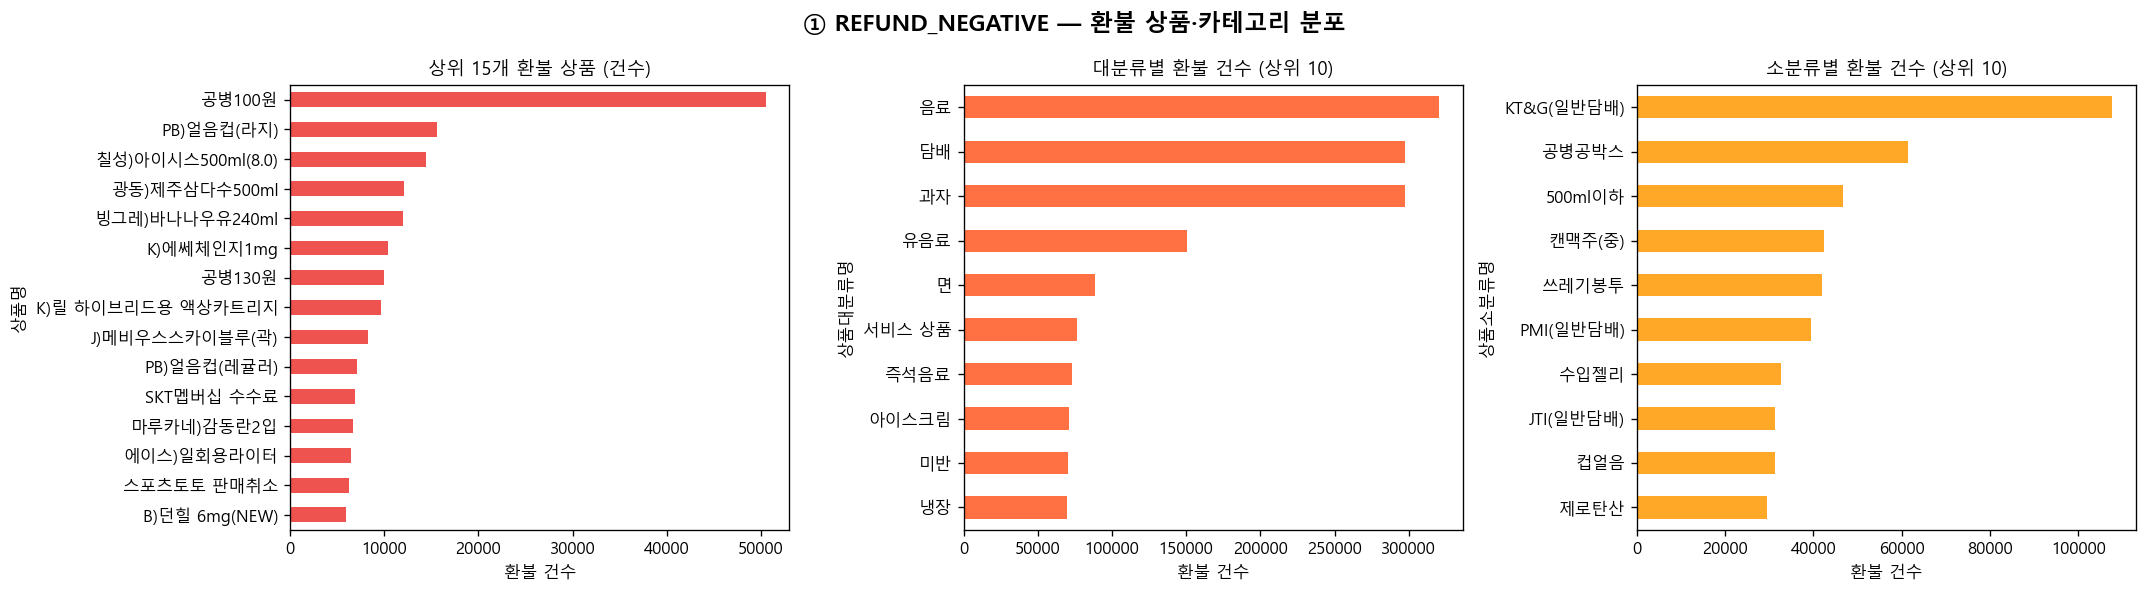


[상위 15개 환불 상품 세부]


,건수,환불금액합
상품명,,
공병100원,50524,-75494096.0
PB)얼음컵(라지),15578,-20203510.0
칠성)아이시스500ml(8.0),14399,-31874984.0
광동)제주삼다수500ml,12065,-29075190.0
빙그레)바나나우유240ml,11951,-29540620.0
K)에쎄체인지1mg,10379,-105907504.0
공병130원,10013,-11132680.0
K)릴 하이브리드용 액상카트리지,9644,-20551000.0
J)메비우스스카이블루(곽),8293,-90337504.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('① REFUND_NEGATIVE — 환불 상품·카테고리 분포', fontsize=14, fontweight='bold')

# 상위 상품 (건수 기준)
top_item_refund = df_refund.groupby('상품명').agg(
    건수=('매출수량', 'count'),
    환불금액합=('매출금액', 'sum')
).sort_values('건수', ascending=False).head(15)

top_item_refund['건수'].plot(kind='barh', ax=axes[0], color='#EF5350')
axes[0].set_title('상위 15개 환불 상품 (건수)', fontsize=11)
axes[0].set_xlabel('환불 건수')
axes[0].invert_yaxis()

# 대분류별 환불 건수
cat_l = df_refund['상품대분류명'].value_counts().head(10)
cat_l.plot(kind='barh', ax=axes[1], color='#FF7043')
axes[1].set_title('대분류별 환불 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('환불 건수')
axes[1].invert_yaxis()

# 소분류별 환불 건수
cat_s = df_refund['상품소분류명'].value_counts().head(10)
cat_s.plot(kind='barh', ax=axes[2], color='#FFA726')
axes[2].set_title('소분류별 환불 건수 (상위 10)', fontsize=11)
axes[2].set_xlabel('환불 건수')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_products.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n[상위 15개 환불 상품 세부]')
display(top_item_refund)

#### 식품 카테고리만 보기

In [5]:
# 식품 카테고리만 골라보기
# 1. 식품 대분류 카테고리 지정 (여기에 원하시는 카테고리들을 넣어주세요)
food_categories = [
    '음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주', 
    '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트', 
    '안주', '신선', '간식', '조미료/건물', '냉동'
]
# 2. REFUND_NEGATIVE 이면서 지정한 식품 대분류에 속하는 데이터만 필터링
df_food_refund = df_refund[
    (df_refund['flag_이상치_유형'] == 'REFUND_NEGATIVE') & 
    (df_refund['상품대분류명'].isin(food_categories))
]
# 3. 결과 확인
display(df_food_refund.head())
print(f"필터링된 식품 REFUND_NEGATIVE 건수: {len(df_food_refund):,}건")

,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,매출수량,매출금액,상품명,상품대분류명,상품중분류명,상품소분류명,판매시간_dt,판매월,판매주,판매일,판매시간대,판매요일,거래_고유키,flag_이상치_유형
1,20250523,140530,51217,2,77129,202782,-2.0,-4600.0,칠성)핫식스더킹퍼플355ml,음료,기능성드링크,에너지음료,2025-05-23 14:05:30,5,21,23,14,금,20250523_51217_2_77129,REFUND_NEGATIVE
2,20250523,160525,58056,1,40307,113974,-1.0,-600.0,롯데)왓따콜라23g,과자,껌,풍선껌,2025-05-23 16:05:25,5,21,23,16,금,20250523_58056_1_40307,REFUND_NEGATIVE
3,20250523,15111,67280,1,39525,150947,-1.0,-1500.0,롯데)스크류바75ml,아이스크림,노벨티,바,2025-05-23 01:51:11,5,21,23,1,금,20250523_67280_1_39525,REFUND_NEGATIVE
4,20250523,12633,11450,2,81168,210972,-3.0,-6600.0,롯데)잇츠와플바닐라140ml,아이스크림,노벨티,모나카,2025-05-23 01:26:33,5,21,23,1,금,20250523_11450_2_81168,REFUND_NEGATIVE
6,20250523,83651,13205,1,52858,104492,-1.0,-3500.0,롯데)몽쉘오리지널204g,과자,비스킷류,파이,2025-05-23 08:36:51,5,21,23,8,금,20250523_13205_1_52858,REFUND_NEGATIVE


필터링된 식품 REFUND_NEGATIVE 건수: 1,490,205건


In [6]:
print(f'REFUND_NEGATIVE: {len(df_food_refund):,}행')
print(f'  관련 상품 수      : {df_food_refund["상품코드"].nunique():,}개')
print(f'  관련 점포 수      : {df_food_refund["점포코드"].nunique():,}개')
print(f'  환불 금액 합계    : {df_food_refund["매출금액"].sum():,.0f}원')
print(f'  평균 환불 금액    : {df_food_refund["매출금액"].mean():,.0f}원')
df_food_refund[['상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']].head(5)

REFUND_NEGATIVE: 1,490,205행
  관련 상품 수      : 8,748개
  관련 점포 수      : 454개
  환불 금액 합계    : -9,772,340,224원
  평균 환불 금액    : -6,558원


,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
1,칠성)핫식스더킹퍼플355ml,에너지음료,-2.0,-4600.0,2025-05-23 14:05:30
2,롯데)왓따콜라23g,풍선껌,-1.0,-600.0,2025-05-23 16:05:25
3,롯데)스크류바75ml,바,-1.0,-1500.0,2025-05-23 01:51:11
4,롯데)잇츠와플바닐라140ml,모나카,-3.0,-6600.0,2025-05-23 01:26:33
6,롯데)몽쉘오리지널204g,파이,-1.0,-3500.0,2025-05-23 08:36:51


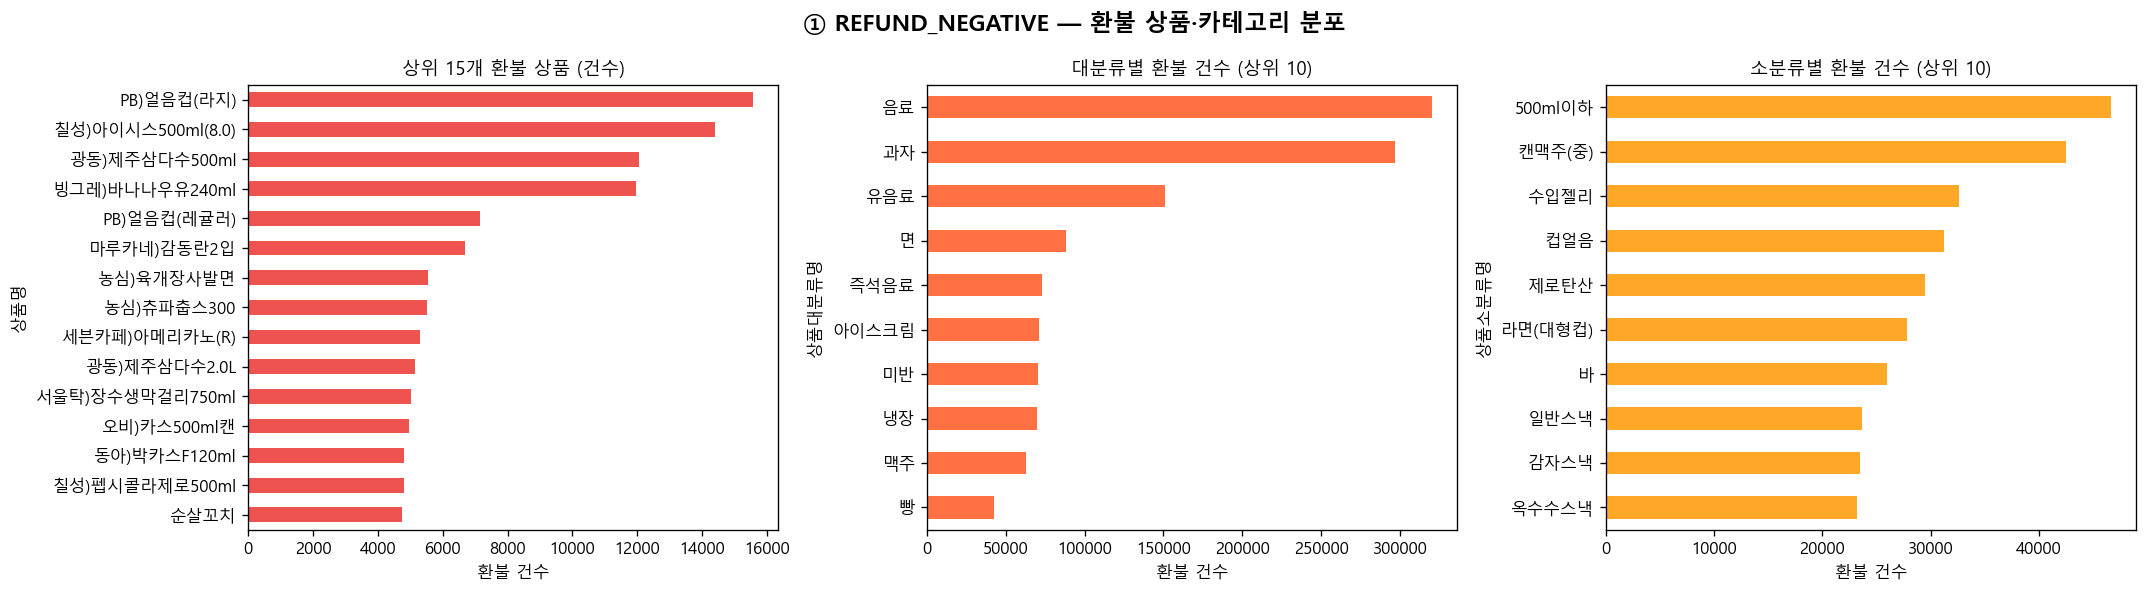


[상위 15개 환불 상품 세부]


,건수,환불금액합
상품명,,
PB)얼음컵(라지),15578,-20203510.0
칠성)아이시스500ml(8.0),14399,-31874984.0
광동)제주삼다수500ml,12065,-29075190.0
빙그레)바나나우유240ml,11951,-29540620.0
PB)얼음컵(레귤러),7135,-7863403.0
마루카네)감동란2입,6684,-19981804.0
농심)육개장사발면,5561,-8175885.0
농심)츄파춥스300,5525,-3446435.0
세븐카페)아메리카노(R),5291,-8183566.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('① REFUND_NEGATIVE — 환불 상품·카테고리 분포', fontsize=14, fontweight='bold')

# 상위 상품 (건수 기준)
top_item_refund = df_food_refund.groupby('상품명').agg(
    건수=('매출수량', 'count'),
    환불금액합=('매출금액', 'sum')
).sort_values('건수', ascending=False).head(15)

top_item_refund['건수'].plot(kind='barh', ax=axes[0], color='#EF5350')
axes[0].set_title('상위 15개 환불 상품 (건수)', fontsize=11)
axes[0].set_xlabel('환불 건수')
axes[0].invert_yaxis()

# 대분류별 환불 건수
cat_l = df_food_refund['상품대분류명'].value_counts().head(10)
cat_l.plot(kind='barh', ax=axes[1], color='#FF7043')
axes[1].set_title('대분류별 환불 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('환불 건수')
axes[1].invert_yaxis()

# 소분류별 환불 건수
cat_s = df_food_refund['상품소분류명'].value_counts().head(10)
cat_s.plot(kind='barh', ax=axes[2], color='#FFA726')
axes[2].set_title('소분류별 환불 건수 (상위 10)', fontsize=11)
axes[2].set_xlabel('환불 건수')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_food_refund_products.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n[상위 15개 환불 상품 세부]')
display(top_item_refund)

### ① - 2. 시간대 / 요일 환불 패턴

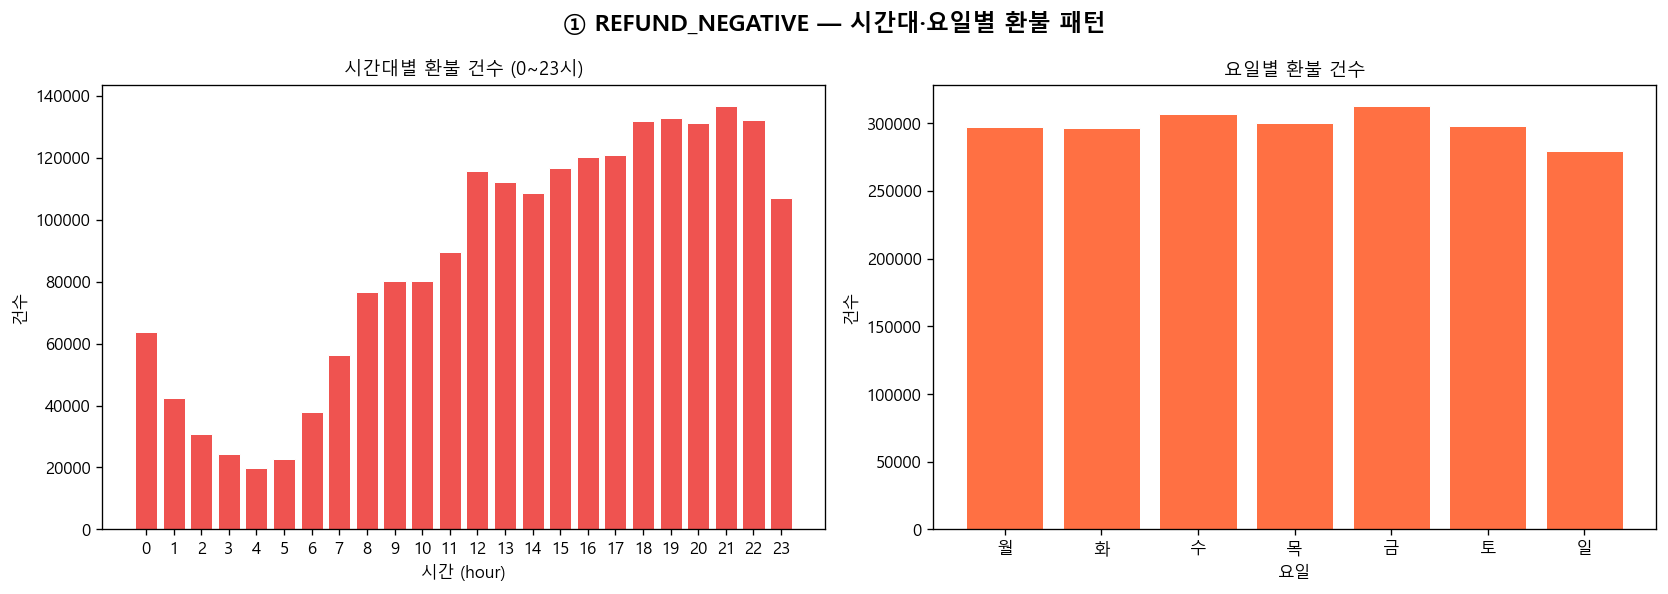

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('① REFUND_NEGATIVE — 시간대·요일별 환불 패턴', fontsize=14, fontweight='bold')

# 시간대별
hour_dist = df_refund['판매시간대'].value_counts().sort_index()
axes[0].bar(hour_dist.index, hour_dist.values, color='#EF5350', edgecolor='white', linewidth=0.6)
axes[0].set_title('시간대별 환불 건수 (0~23시)', fontsize=11)
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('건수')
axes[0].set_xticks(range(0, 24))

# 요일별
day_order = ['월', '화', '수', '목', '금', '토', '일']
day_dist  = df_refund['판매요일'].value_counts().reindex(day_order).fillna(0)
axes[1].bar(day_dist.index, day_dist.values, color='#FF7043', edgecolor='white', linewidth=0.6)
axes[1].set_title('요일별 환불 건수', fontsize=11)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_time_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

#### 식품 카테고리만 보기

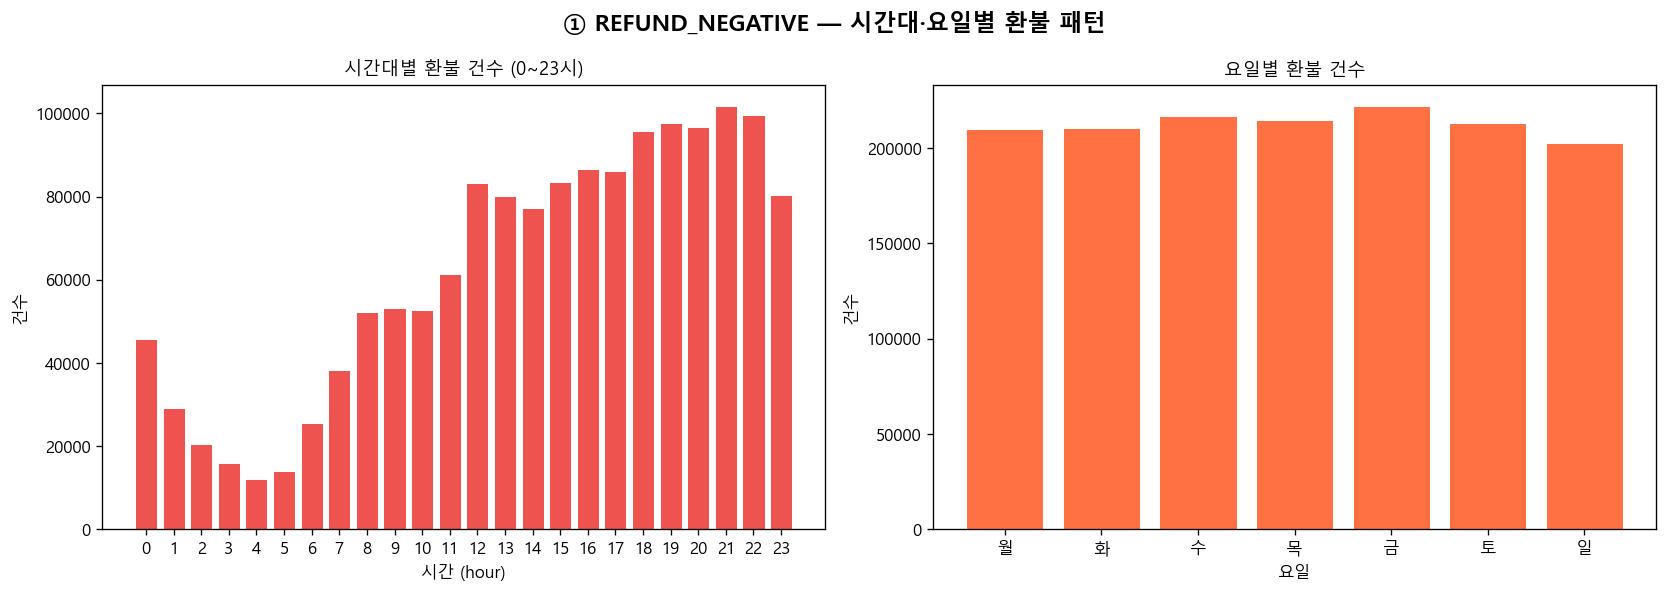

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('① REFUND_NEGATIVE — 시간대·요일별 환불 패턴', fontsize=14, fontweight='bold')

# 시간대별
hour_dist = df_food_refund['판매시간대'].value_counts().sort_index()
axes[0].bar(hour_dist.index, hour_dist.values, color='#EF5350', edgecolor='white', linewidth=0.6)
axes[0].set_title('시간대별 환불 건수 (0~23시)', fontsize=11)
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('건수')
axes[0].set_xticks(range(0, 24))

# 요일별
day_order = ['월', '화', '수', '목', '금', '토', '일']
day_dist  = df_food_refund['판매요일'].value_counts().reindex(day_order).fillna(0)
axes[1].bar(day_dist.index, day_dist.values, color='#FF7043', edgecolor='white', linewidth=0.6)
axes[1].set_title('요일별 환불 건수', fontsize=11)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_time_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

### ① - 3. 환불 시간 텀 분석

동일 점포·상품 기준으로 환불 직전 **가장 가까운 정상 구매 시점**을 찾아 시간 텀을 계산합니다.  
> ⏳ 메인 파일(2.9 GB)에서 해당 상품의 NORMAL 행을 로드하므로 시간이 걸릴 수 있습니다.

In [15]:
# ── 상위 50개 환불 상품만 대상으로 분석 (메모리·시간 절감) ──────────────────
TOP_N = 50
top_refund_items = df_refund['상품코드'].value_counts().head(TOP_N).index.tolist()
print(f'시간 텀 분석 대상: 상위 {TOP_N}개 상품')

# ── 해당 상품의 NORMAL 행 로드 ────────────────────────────────────────────────
print('메인 Parquet에서 NORMAL 행 로드 중...')
df_normal_r = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', '상품코드', '상품명', '판매시간_dt'],
    filters=[
        ('flag_이상치_유형', '=', 'NORMAL'),
        ('상품코드', 'in', top_refund_items)
    ]
)
df_normal_r['판매시간_dt'] = pd.to_datetime(df_normal_r['판매시간_dt'], errors='coerce')
df_normal_r = df_normal_r.dropna(subset=['판매시간_dt'])
print(f'  NORMAL 행 로드 완료: {len(df_normal_r):,}행')

# ── merge_asof: 각 환불에 대해 직전 가장 가까운 정상 구매 매칭 ─────────────
refund_sub = (
    df_refund[df_refund['상품코드'].isin(top_refund_items)]
    [['점포코드', '상품코드', '상품명', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '환불시간'})
    .dropna(subset=['환불시간'])
    .sort_values('환불시간')
)
normal_sub = (
    df_normal_r[['점포코드', '상품코드', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '구매시간'})
    .sort_values('구매시간')
)

df_gap_r = pd.merge_asof(
    refund_sub,
    normal_sub,
    left_on='환불시간',
    right_on='구매시간',
    by=['점포코드', '상품코드'],
    direction='backward'   # 환불 직전 가장 가까운 구매
)
df_gap_r['시간_텀_h'] = (df_gap_r['환불시간'] - df_gap_r['구매시간']).dt.total_seconds() / 3600
df_gap_r['일_텀']    = (df_gap_r['시간_텀_h'] / 24).round(1)

valid_gap = df_gap_r.dropna(subset=['시간_텀_h'])
valid_gap = valid_gap[valid_gap['시간_텀_h'] >= 0]  # 음수(매칭 실패) 제거

매칭률 = len(valid_gap) / len(refund_sub) * 100
print(f'\n매칭 성공: {len(valid_gap):,}건 / {len(refund_sub):,}건 ({매칭률:.1f}%)')
print(f'  중앙 시간 텀 : {valid_gap["시간_텀_h"].median():.1f}시간')
print(f'  평균 시간 텀 : {valid_gap["시간_텀_h"].mean():.1f}시간')
print(f'  중앙 일수 텀 : {valid_gap["일_텀"].median():.1f}일')

del df_normal_r
gc.collect()

시간 텀 분석 대상: 상위 50개 상품
메인 Parquet에서 NORMAL 행 로드 중...
  NORMAL 행 로드 완료: 15,463,308행

매칭 성공: 318,026건 / 340,299건 (93.5%)
  중앙 시간 텀 : 0.0시간
  평균 시간 텀 : 161.5시간
  중앙 일수 텀 : 0.0일


17692

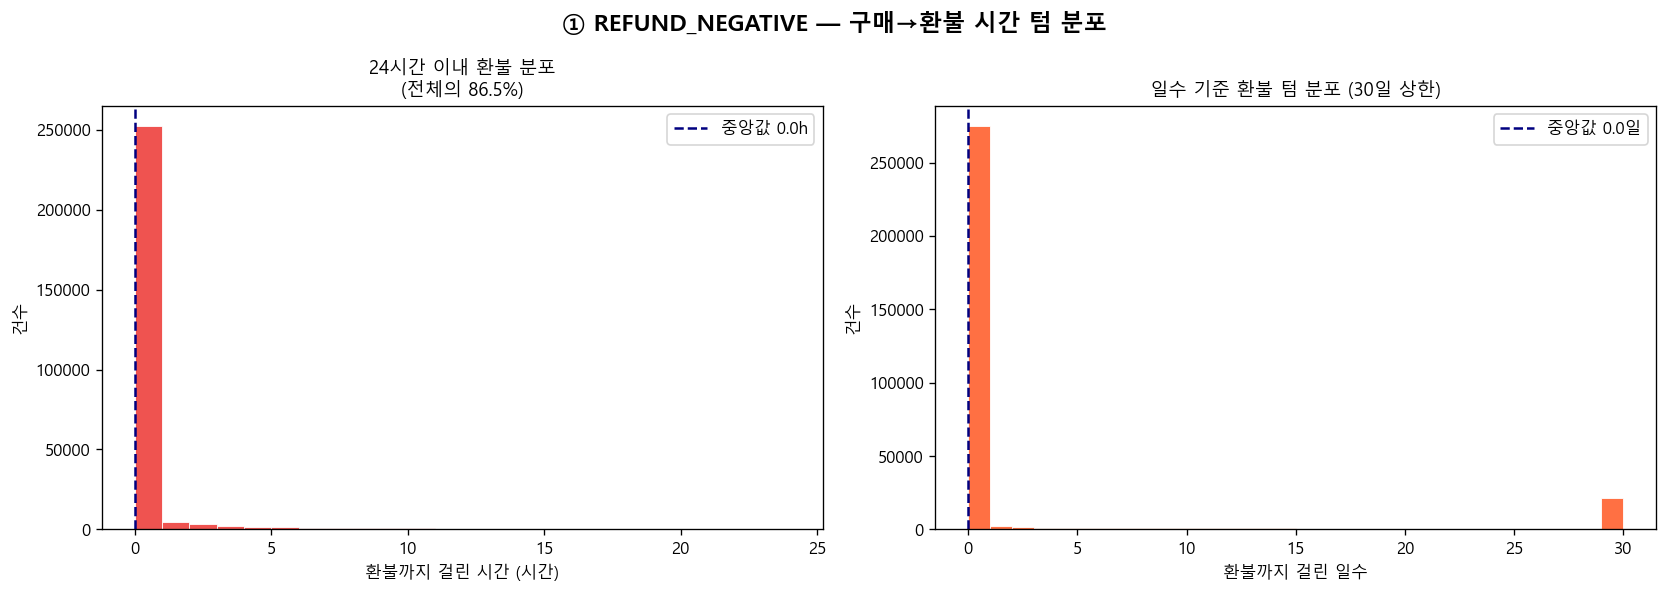

[환불 텀 구간 비중]
  당일(0~24h)   : 275,037건  (86.5%)
  1~3일        :   3,650건  (1.1%)
  3~7일        :   4,473건  (1.4%)
  7일 초과       :  34,866건  (11.0%)


In [16]:
# 시간 텀 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('① REFUND_NEGATIVE — 구매→환불 시간 텀 분포', fontsize=14, fontweight='bold')

# 24시간 이내 (당일 환불)
within_24h = valid_gap[valid_gap['시간_텀_h'] <= 24]['시간_텀_h']
axes[0].hist(within_24h, bins=24, color='#EF5350', edgecolor='white', linewidth=0.5)
axes[0].set_title(f'24시간 이내 환불 분포\n(전체의 {len(within_24h)/len(valid_gap)*100:.1f}%)', fontsize=11)
axes[0].set_xlabel('환불까지 걸린 시간 (시간)')
axes[0].set_ylabel('건수')
axes[0].axvline(within_24h.median(), color='navy', linestyle='--', label=f'중앙값 {within_24h.median():.1f}h')
axes[0].legend()

# 일수 기준 (전체 분포, 30일 상한)
day_dist = valid_gap['일_텀'].clip(upper=30)
axes[1].hist(day_dist, bins=30, color='#FF7043', edgecolor='white', linewidth=0.5)
axes[1].set_title('일수 기준 환불 텀 분포 (30일 상한)', fontsize=11)
axes[1].set_xlabel('환불까지 걸린 일수')
axes[1].set_ylabel('건수')
axes[1].axvline(valid_gap['일_텀'].median(), color='navy', linestyle='--',
                label=f'중앙값 {valid_gap["일_텀"].median():.1f}일')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_refund_time_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

# 당일(0~24h) / 1~3일 / 3일+ 비중
print('[환불 텀 구간 비중]')
for label, lo, hi in [('당일(0~24h)', 0, 24), ('1~3일', 24, 72), ('3~7일', 72, 168), ('7일 초과', 168, 1e9)]:
    cnt = ((valid_gap['시간_텀_h'] >= lo) & (valid_gap['시간_텀_h'] < hi)).sum()
    print(f'  {label:<12}: {cnt:>7,}건  ({cnt/len(valid_gap)*100:.1f}%)')

In [17]:
# ── 14일(2주) 이상 걸린 환불 건 필터링 ──────────────────────────────────────
long_term_refunds = valid_gap[valid_gap['일_텀'] >= 14]

print(f"환불까지 14일 이상 소요된 건수: {len(long_term_refunds):,}건")

if len(long_term_refunds) > 0:
    # 어떤 상품들이 장기 환불이 많이 일어났는지 집계 (상품명 기준 내림차순)
    long_term_summary = (
        long_term_refunds.groupby(['상품코드', '상품명'])
        .agg(
            장기환불_건수=('일_텀', 'count'),
            평균_일텀=('일_텀', 'mean'),
            최대_일텀=('일_텀', 'max')
        )
        .sort_values('장기환불_건수', ascending=False)
        .reset_index()
    )
    
    #display(long_term_summary)
    
    # 상세 내역이 보고 싶을 경우
    display(long_term_refunds.sort_values('일_텀', ascending=False).head(10))
else:
    print("14일 이상 걸린 환불 건이 없습니다.")


환불까지 14일 이상 소요된 건수: 29,305건


,점포코드,상품코드,상품명,환불시간,구매시간,시간_텀_h,일_텀
337086,58098,900080,공병100원,2025-12-28 11:56:39,2025-01-08 14:53:02,8493.060278,353.9
329772,18308,900081,공병130원,2025-12-19 12:48:10,2025-01-08 11:50:31,8280.960833,345.0
333238,14350,900080,공병100원,2025-12-23 13:19:33,2025-01-15 05:33:23,8215.769444,342.3
332332,14350,900080,공병100원,2025-12-22 13:27:33,2025-01-15 05:33:23,8191.902778,341.3
326044,58098,900080,공병100원,2025-12-14 20:37:42,2025-01-08 14:53:02,8165.744444,340.2
329051,54436,900081,공병130원,2025-12-18 15:02:15,2025-01-13 12:17:23,8138.747778,339.1
339907,68556,900080,공병100원,2025-12-31 16:58:05,2025-01-27 20:21:56,8108.602500,337.9
330643,11286,900080,공병100원,2025-12-20 13:07:49,2025-01-17 15:39:02,8085.479722,336.9
327157,54436,900081,공병130원,2025-12-16 08:55:51,2025-01-13 12:17:23,8084.641111,336.9
326404,54436,900081,공병130원,2025-12-15 09:58:25,2025-01-13 12:17:23,8061.683889,335.9


#### 식품 카테고리만 보기

In [18]:
# ── 상위 50개 환불 상품만 대상으로 분석 (메모리·시간 절감) ──────────────────
TOP_N = 50
top_refund_items = df_food_refund['상품코드'].value_counts().head(TOP_N).index.tolist()
print(f'시간 텀 분석 대상: 상위 {TOP_N}개 상품')

# ── 해당 상품의 NORMAL 행 로드 ────────────────────────────────────────────────
print('메인 Parquet에서 NORMAL 행 로드 중...')
df_normal_r = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', '상품코드', '상품명', '판매시간_dt'],
    filters=[
        ('flag_이상치_유형', '=', 'NORMAL'),
        ('상품코드', 'in', top_refund_items)
    ]
)
df_normal_r['판매시간_dt'] = pd.to_datetime(df_normal_r['판매시간_dt'], errors='coerce')
df_normal_r = df_normal_r.dropna(subset=['판매시간_dt'])
print(f'  NORMAL 행 로드 완료: {len(df_normal_r):,}행')

# ── merge_asof: 각 환불에 대해 직전 가장 가까운 정상 구매 매칭 ─────────────
refund_sub = (
    df_food_refund[df_food_refund['상품코드'].isin(top_refund_items)]
    [['점포코드', '상품코드', '상품명', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '환불시간'})
    .dropna(subset=['환불시간'])
    .sort_values('환불시간')
)
normal_sub = (
    df_normal_r[['점포코드', '상품코드', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '구매시간'})
    .sort_values('구매시간')
)

df_gap_r = pd.merge_asof(
    refund_sub,
    normal_sub,
    left_on='환불시간',
    right_on='구매시간',
    by=['점포코드', '상품코드'],
    direction='backward'   # 환불 직전 가장 가까운 구매
)
df_gap_r['시간_텀_h'] = (df_gap_r['환불시간'] - df_gap_r['구매시간']).dt.total_seconds() / 3600
df_gap_r['일_텀']    = (df_gap_r['시간_텀_h'] / 24).round(1)

valid_gap = df_gap_r.dropna(subset=['시간_텀_h'])
valid_gap = valid_gap[valid_gap['시간_텀_h'] >= 0]  # 음수(매칭 실패) 제거

매칭률 = len(valid_gap) / len(refund_sub) * 100
print(f'\n매칭 성공: {len(valid_gap):,}건 / {len(refund_sub):,}건 ({매칭률:.1f}%)')
print(f'  중앙 시간 텀 : {valid_gap["시간_텀_h"].median():.1f}시간')
print(f'  평균 시간 텀 : {valid_gap["시간_텀_h"].mean():.1f}시간')
print(f'  중앙 일수 텀 : {valid_gap["일_텀"].median():.1f}일')

del df_normal_r
gc.collect()

시간 텀 분석 대상: 상위 50개 상품
메인 Parquet에서 NORMAL 행 로드 중...
  NORMAL 행 로드 완료: 11,709,485행

매칭 성공: 223,023건 / 223,035건 (100.0%)
  중앙 시간 텀 : 0.0시간
  평균 시간 텀 : 0.8시간
  중앙 일수 텀 : 0.0일


8943

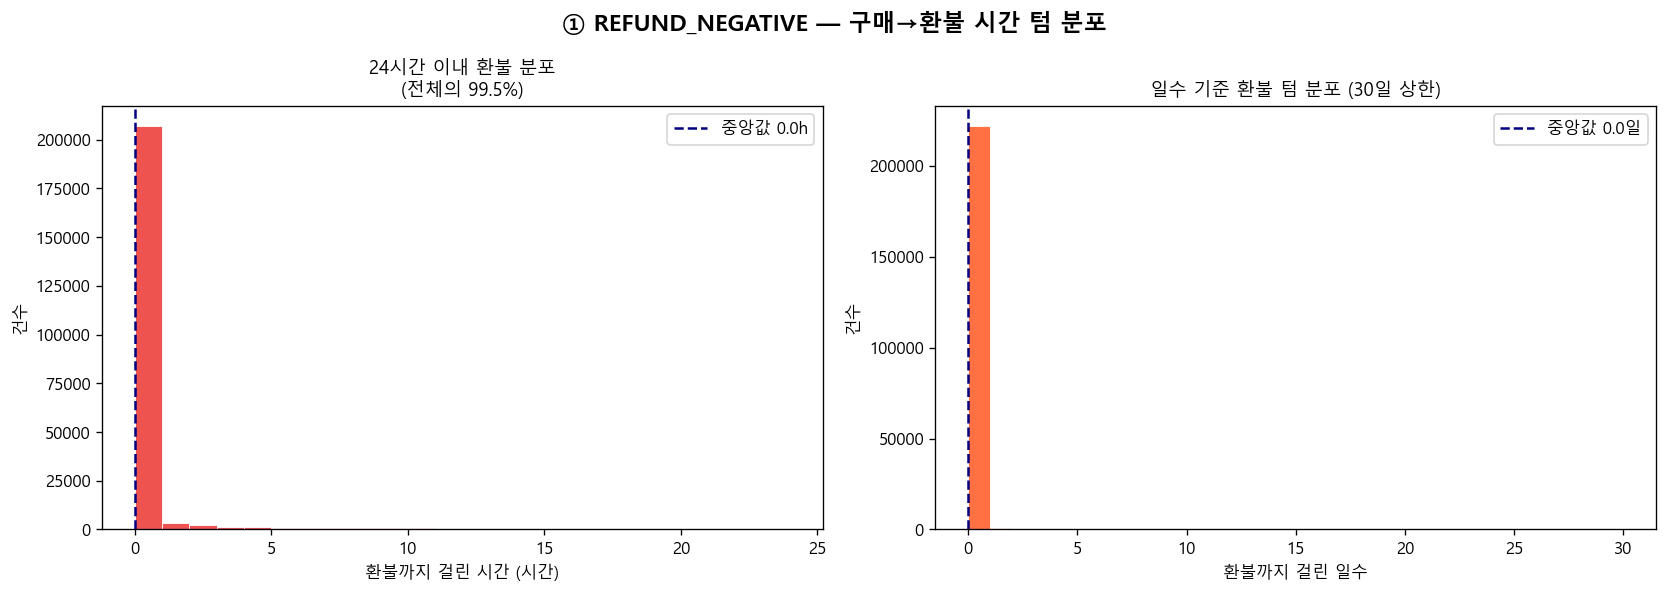

[환불 텀 구간 비중]
  당일(0~24h)   : 222,018건  (99.5%)
  1~3일        :     819건  (0.4%)
  3~7일        :     131건  (0.1%)
  7일 초과       :      55건  (0.0%)


In [19]:
# 시간 텀 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('① REFUND_NEGATIVE — 구매→환불 시간 텀 분포', fontsize=14, fontweight='bold')

# 24시간 이내 (당일 환불)
within_24h = valid_gap[valid_gap['시간_텀_h'] <= 24]['시간_텀_h']
axes[0].hist(within_24h, bins=24, color='#EF5350', edgecolor='white', linewidth=0.5)
axes[0].set_title(f'24시간 이내 환불 분포\n(전체의 {len(within_24h)/len(valid_gap)*100:.1f}%)', fontsize=11)
axes[0].set_xlabel('환불까지 걸린 시간 (시간)')
axes[0].set_ylabel('건수')
axes[0].axvline(within_24h.median(), color='navy', linestyle='--', label=f'중앙값 {within_24h.median():.1f}h')
axes[0].legend()

# 일수 기준 (전체 분포, 30일 상한)
day_dist = valid_gap['일_텀'].clip(upper=30)
axes[1].hist(day_dist, bins=30, color='#FF7043', edgecolor='white', linewidth=0.5)
axes[1].set_title('일수 기준 환불 텀 분포 (30일 상한)', fontsize=11)
axes[1].set_xlabel('환불까지 걸린 일수')
axes[1].set_ylabel('건수')
axes[1].axvline(valid_gap['일_텀'].median(), color='navy', linestyle='--',
                label=f'중앙값 {valid_gap["일_텀"].median():.1f}일')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_food_refund_time_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

# 당일(0~24h) / 1~3일 / 3일+ 비중
print('[환불 텀 구간 비중]')
for label, lo, hi in [('당일(0~24h)', 0, 24), ('1~3일', 24, 72), ('3~7일', 72, 168), ('7일 초과', 168, 1e9)]:
    cnt = ((valid_gap['시간_텀_h'] >= lo) & (valid_gap['시간_텀_h'] < hi)).sum()
    print(f'  {label:<12}: {cnt:>7,}건  ({cnt/len(valid_gap)*100:.1f}%)')

In [20]:
# ── 7일(1주) 이상 걸린 환불 건 필터링 ──────────────────────────────────────
long_term_refunds = valid_gap[valid_gap['일_텀'] >= 7]

print(f"환불까지 14일 이상 소요된 건수: {len(long_term_refunds):,}건")

if len(long_term_refunds) > 0:
    # 어떤 상품들이 장기 환불이 많이 일어났는지 집계 (상품명 기준 내림차순)
    long_term_summary = (
        long_term_refunds.groupby(['상품코드', '상품명'])
        .agg(
            장기환불_건수=('일_텀', 'count'),
            평균_일텀=('일_텀', 'mean'),
            최대_일텀=('일_텀', 'max')
        )
        .sort_values('장기환불_건수', ascending=False)
        .reset_index()
    )
    
    #display(long_term_summary)
    
    # 상세 내역이 보고 싶을 경우
    display(long_term_refunds.sort_values('일_텀', ascending=False).head(10))
else:
    print("14일 이상 걸린 환불 건이 없습니다.")


환불까지 14일 이상 소요된 건수: 57건


,점포코드,상품코드,상품명,환불시간,구매시간,시간_텀_h,일_텀
163948,64157,202732,PB)내몸애70% 500ml,2025-09-16 21:51:31,2025-06-24 13:24:36,2024.448611,84.4
131350,64157,160052,칠성)칠성사이다500ml,2025-08-03 08:20:18,2025-05-23 00:05:13,1736.251389,72.3
123198,64157,160052,칠성)칠성사이다500ml,2025-07-24 01:08:33,2025-05-23 00:05:13,1489.055556,62.0
131346,64157,061417,서울)커피우유300ml,2025-08-03 08:17:45,2025-06-11 23:35:27,1256.705000,52.4
208583,12487,014287,롯데)NEW참치마요네즈삼각,2025-12-04 21:52:51,2025-10-15 21:52:33,1200.005000,50.0
21624,12487,201737,PB)아이시스2L(6입),2025-02-17 14:15:57,2025-01-03 12:14:26,1082.025278,45.1
167018,64157,202360,칠성)아이시스에코500ml,2025-09-21 23:28:19,2025-08-10 10:35:08,1020.886389,42.5
167011,64157,202360,칠성)아이시스에코500ml,2025-09-21 23:25:12,2025-08-10 10:35:08,1020.834444,42.5
166426,64157,202360,칠성)아이시스에코500ml,2025-09-20 23:57:11,2025-08-10 10:35:08,997.367500,41.6
165537,64157,202360,칠성)아이시스에코500ml,2025-09-19 15:36:16,2025-08-10 10:35:08,965.018889,40.2


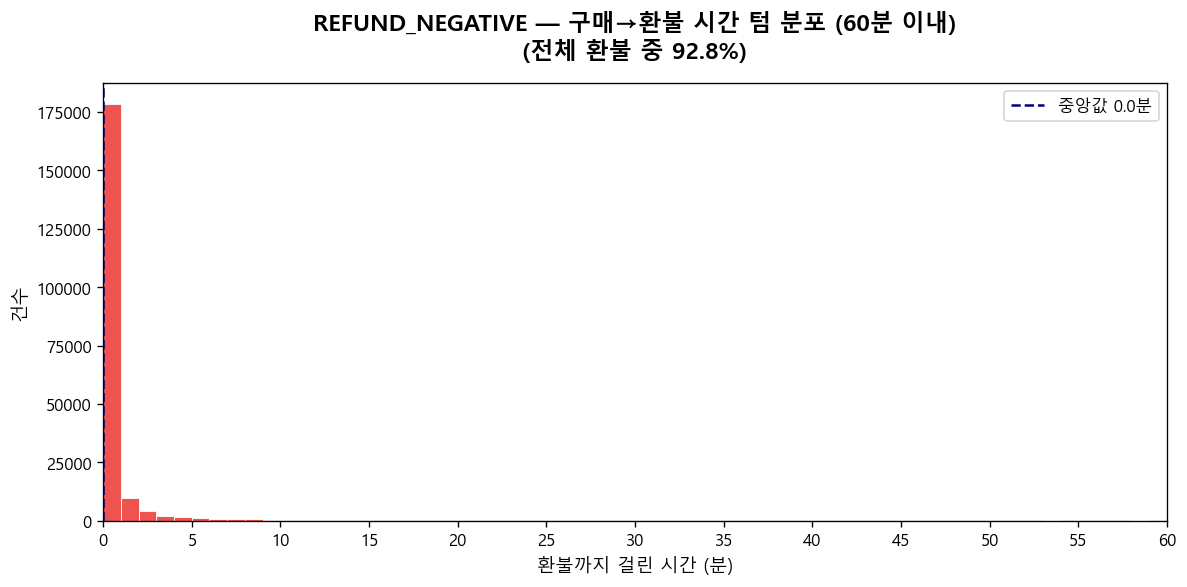


[당일(24시간 이내) 시간별 환불 텀 비중]
24시간 이내 총 환불 건수: 222,018건 (전체의 99.5%)

   0 ~ 1  시간 경과: 206,990건  ( 93.2%)
   1 ~ 2  시간 경과:   3,243건  (  1.5%)
   2 ~ 3  시간 경과:   2,053건  (  0.9%)
   3 ~ 4  시간 경과:   1,444건  (  0.7%)
   4 ~ 5  시간 경과:   1,100건  (  0.5%)
   5 ~ 6  시간 경과:     983건  (  0.4%)
   6 ~ 7  시간 경과:     815건  (  0.4%)
   7 ~ 8  시간 경과:     664건  (  0.3%)
   8 ~ 9  시간 경과:     665건  (  0.3%)
   9 ~ 10 시간 경과:     536건  (  0.2%)
  10 ~ 11 시간 경과:     516건  (  0.2%)
  11 ~ 12 시간 경과:     436건  (  0.2%)
  12 ~ 13 시간 경과:     426건  (  0.2%)
  13 ~ 14 시간 경과:     360건  (  0.2%)
  14 ~ 15 시간 경과:     315건  (  0.1%)
  15 ~ 16 시간 경과:     264건  (  0.1%)
  16 ~ 17 시간 경과:     234건  (  0.1%)
  17 ~ 18 시간 경과:     184건  (  0.1%)
  18 ~ 19 시간 경과:     159건  (  0.1%)
  19 ~ 20 시간 경과:     142건  (  0.1%)
  20 ~ 21 시간 경과:     128건  (  0.1%)
  21 ~ 22 시간 경과:     119건  (  0.1%)
  22 ~ 23 시간 경과:     106건  (  0.0%)
  23 ~ 24 시간 경과:     136건  (  0.1%)


In [22]:
# '분 단위' 환불 텀 컬럼 추가
valid_gap['시간_텀_m'] = valid_gap['시간_텀_h'] * 60

# ── 1. 60분 이내 (분 단위) 분포 시각화 (단일 그래프) ─────────────────────────
within_60m = valid_gap[valid_gap['시간_텀_m'] <= 60]['시간_텀_m']

plt.figure(figsize=(10, 5))
plt.hist(within_60m, bins=60, range=(0, 60), color='#EF5350', edgecolor='white', linewidth=0.5)

plt.title(f'REFUND_NEGATIVE — 구매→환불 시간 텀 분포 (60분 이내)\n(전체 환불 중 {len(within_60m)/len(valid_gap)*100:.1f}%)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('환불까지 걸린 시간 (분)', fontsize=11)
plt.ylabel('건수', fontsize=11)
plt.xlim(0, 60)
plt.xticks(range(0, 61, 5)) # x축 눈금을 5분 단위로 표시

median_m = within_60m.median()
plt.axvline(median_m, color='navy', linestyle='--', label=f'중앙값 {median_m:.1f}분')
plt.legend()

plt.tight_layout()
# 경로 맞게 주석 해제하여 사용하세요
# plt.savefig(os.path.join(FINAL_DIR, 'fig_food_refund_time_gap_mins.png'), dpi=150, bbox_inches='tight')
plt.show()


# ── 2. 하루(24시간) 내 환불건 대상 시간대별 통계 ───────────────────────────
within_24h_total = len(valid_gap[valid_gap['시간_텀_h'] <= 24])

print('\n[당일(24시간 이내) 시간별 환불 텀 비중]')
print(f"24시간 이내 총 환불 건수: {within_24h_total:>7,}건 (전체의 {within_24h_total/len(valid_gap)*100:.1f}%)\n")

# 0~1시, 1~2시 ... 23~24시까지 1시간 단위 반복
for h in range(24):
    cnt = ((valid_gap['시간_텀_h'] >= h) & (valid_gap['시간_텀_h'] < h + 1)).sum()
    if within_24h_total > 0:
        pct = cnt / within_24h_total * 100
    else:
        pct = 0
    print(f'  {h:>2} ~ {h+1:<2} 시간 경과: {cnt:>7,}건  ({pct:>5.1f}%)')

In [24]:
# ── 5분 이하 걸린 환불 건 필터링 ──────────────────────────────────────
# 주의: 분 단위 필터링이므로 '시간_텀_m' 컬럼 사용
short_term_refunds = valid_gap[valid_gap['시간_텀_m'] <= 5]

print(f"환불까지 5분 이하 소요된 건수: {len(short_term_refunds):,}건")

if len(short_term_refunds) > 0:
    # 어떤 상품들이 단기 환불이 많이 일어났는지 집계 (상품명 기준 내림차순)
    short_term_summary = (
        short_term_refunds.groupby(['상품코드', '상품명'])
        .agg(
            단기환불_건수=('시간_텀_m', 'count'),  # 변수명 일치
            평균_분텀=('시간_텀_m', 'mean'),       # '일텀' -> '분텀'
            최대_분텀=('시간_텀_m', 'max')
        )
        .sort_values('단기환불_건수', ascending=False)
        .reset_index()
    )
    
    # 요약표 확인 (주석 해제)
    display(short_term_summary.head(10))
    
    # 상세 내역이 보고 싶을 경우
    # display(short_term_refunds.sort_values('시간_텀_m', ascending=False).head(10))
else:
    print("5분 이하 걸린 환불 건이 없습니다.")  # 문구 수정


환불까지 5분 이하 소요된 건수: 195,940건


,상품코드,상품명,단기환불_건수,평균_분텀,최대_분텀
0,107128,PB)얼음컵(라지),14352,0.218407,5.000000
1,201105,칠성)아이시스500ml(8.0),13354,0.262241,5.000000
2,201275,광동)제주삼다수500ml,10487,0.308466,4.950000
3,070012,빙그레)바나나우유240ml,9502,0.415818,5.000000
4,107127,PB)얼음컵(레귤러),6516,0.219649,5.000000
5,071778,마루카네)감동란2입,5494,0.402891,5.000000
6,803186,농심)츄파춥스300,5026,0.202782,4.916667
7,052382,세븐카페)아메리카노(R),4998,0.285307,4.966667
8,202369,칠성)펩시콜라제로500ml,4607,0.147395,4.833333
9,132168,농심)육개장사발면,4559,0.417624,5.000000


### 환불 이상치 결론 (식품 카테고리 한해서)

- 식품 223,023건 중 195,940건이 5분 내에 환불됨. -> 거래 데이터 남겨서 상품단위로 묶을 때 반영되도록 함.

---
## ② GIFT_OR_ZERO_QTY — 증정품 여부 확인

**수량=0 OR 금액=0** 인 행. 주요 가설:
- 번들증정(N+1) 행사에서 무료 제공되는 상품 → **동일 거래에 정상 구매 행 공존 여부** 확인
- 금액=0인데 수량>0 : 증정품 가능성 높음
- 수량=0 : POC 단위 집계 오류 또는 취소 후 재처리 가능성

#### 식품만 보기

In [26]:
# 1. 식품 대분류 카테고리 지정
food_categories = [
    '음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주', 
    '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트', 
    '안주', '신선', '간식', '조미료/건물', '냉동'
]
# 2. 파생 파라미터 적용 (GIFT_OR_ZERO_QTY 이면서 식품 대분류인 것만 필터링)
df_gift = df_review[
    (df_review['flag_이상치_유형'] == 'GIFT_OR_ZERO_QTY') &
    (df_review['상품대분류명'].isin(food_categories))
].copy()

print(f'GIFT_OR_ZERO_QTY: {len(df_gift):,}행')

# 세부 구분: AMT=0 / QTY=0 / 둘 다 0
amt0  = (df_gift['매출금액'] == 0) & (df_gift['매출수량'] != 0)
qty0  = (df_gift['매출수량'] == 0) & (df_gift['매출금액'] != 0)
both0 = (df_gift['매출금액'] == 0) & (df_gift['매출수량'] == 0)

print(f'\n  금액=0, 수량>0 (증정품 유력)  : {amt0.sum():>8,}건  ({amt0.sum()/len(df_gift)*100:.2f}%)')
print(f'  수량=0, 금액>0 (집계 오류 의심): {qty0.sum():>8,}건  ({qty0.sum()/len(df_gift)*100:.2f}%)')
print(f'  수량=0, 금액=0 (완전 0건)      : {both0.sum():>8,}건  ({both0.sum()/len(df_gift)*100:.2f}%)')
print()

# 수량 분포 (amt=0인 행)
print('[금액=0 행의 매출수량 분포]')
display(df_gift[amt0]['매출수량'].value_counts().head(10).to_frame())

GIFT_OR_ZERO_QTY: 39,224행

  금액=0, 수량>0 (증정품 유력)  :   39,224건  (100.00%)
  수량=0, 금액>0 (집계 오류 의심):        0건  (0.00%)
  수량=0, 금액=0 (완전 0건)      :        0건  (0.00%)

[금액=0 행의 매출수량 분포]


,count
매출수량,
1.0,33161
2.0,3926
3.0,1324
4.0,443
6.0,116
5.0,70
10.0,47
20.0,33
8.0,22


### ② - 1. 상위 증정 상품 & 카테고리

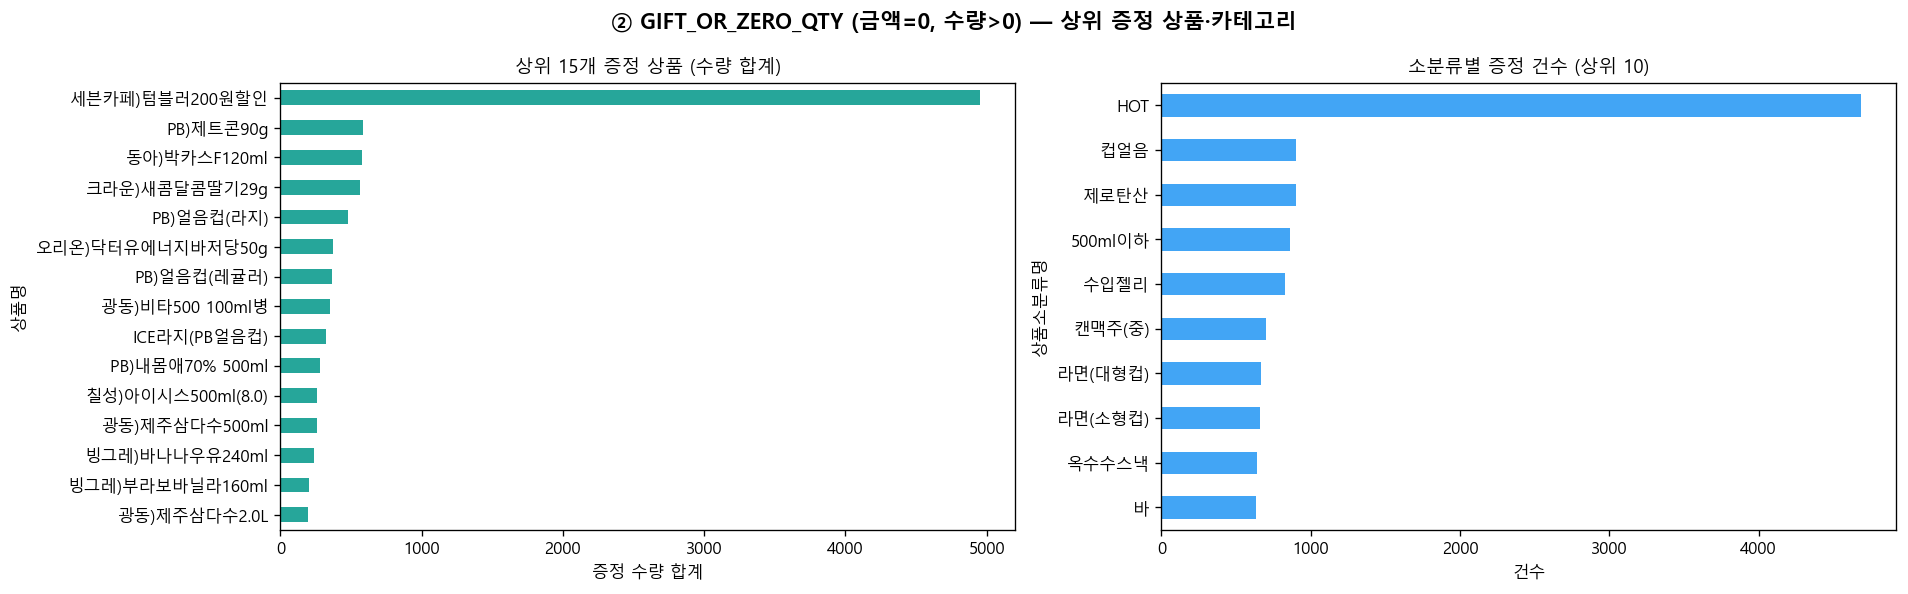

In [27]:
# 금액=0, 수량>0 행만 (증정품 유력)
df_gift_amt0 = df_gift[amt0].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('② GIFT_OR_ZERO_QTY (금액=0, 수량>0) — 상위 증정 상품·카테고리', fontsize=13, fontweight='bold')

top_gift_items = df_gift_amt0.groupby('상품명')['매출수량'].sum().sort_values(ascending=False).head(15)
top_gift_items.plot(kind='barh', ax=axes[0], color='#26A69A')
axes[0].set_title('상위 15개 증정 상품 (수량 합계)', fontsize=11)
axes[0].set_xlabel('증정 수량 합계')
axes[0].invert_yaxis()

top_gift_cat = df_gift_amt0['상품소분류명'].value_counts().head(10)
top_gift_cat.plot(kind='barh', ax=axes[1], color='#42A5F5')
axes[1].set_title('소분류별 증정 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('건수')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_gift_products.png'), dpi=150, bbox_inches='tight')
plt.show()

### ② - 2. 동일 거래 내 정상 구매 공존 여부 (증정품 검증)

샘플 거래의 전체 영수증 구성을 불러와,  
*금액=0 행과 동일 상품코드의 정상 구매(NORMAL)가 같은 거래에 존재하는지* 확인합니다.  
→ 존재하면 **번들증정 증정행**, 없으면 **다른 원인(시스템 보정 등)** 가능성.

> ⏳ 메인 파일에서 샘플 거래를 로드합니다.

In [28]:
# 금액=0 행에서 샘플 거래_고유키 추출 (최대 300건)
SAMPLE_N = 300
gift_sample_keys = (
    df_gift_amt0['거래_고유키'].drop_duplicates()
    .sample(n=min(SAMPLE_N, df_gift_amt0['거래_고유키'].nunique()), random_state=42)
    .tolist()
)
print(f'샘플 거래 수: {len(gift_sample_keys):,}건')

# 해당 거래의 전체 행 로드 (메인 파일에서 거래_고유키 필터)
print('메인 Parquet에서 샘플 거래 전체 행 로드 중...')
df_gift_tx = pd.read_parquet(
    PATH_MAIN,
    columns=['거래_고유키', '상품코드', '상품명', '매출수량', '매출금액', 'flag_이상치_유형'],
    filters=[('거래_고유키', 'in', gift_sample_keys)]
)
print(f'  로드 완료: {len(df_gift_tx):,}행')

# 증정행(금액=0)과 정상행(NORMAL) 각각 추출
gift_rows   = df_gift_tx[df_gift_tx['매출금액'] == 0][['거래_고유키', '상품코드']].rename(columns={'상품코드': '증정_상품코드'})
normal_rows = df_gift_tx[df_gift_tx['flag_이상치_유형'] == 'NORMAL'][['거래_고유키', '상품코드']].rename(columns={'상품코드': '정상_상품코드'})

# 동일 거래 내 동일 상품 공존 여부
cooc = gift_rows.merge(normal_rows, on='거래_고유키')
same_item_cooc = cooc[cooc['증정_상품코드'] == cooc['정상_상품코드']]
diff_item_cooc = cooc[cooc['증정_상품코드'] != cooc['정상_상품코드']]

cooc_tx = same_item_cooc['거래_고유키'].nunique()
only_gift_tx = len(set(gift_sample_keys) - set(normal_rows['거래_고유키']))

print(f'\n[샘플 {len(gift_sample_keys)}건 분석 결과]')
print(f'  동일 상품 정상 구매 공존 (증정품 확인)  : {cooc_tx:>5}건  ({cooc_tx/len(gift_sample_keys)*100:.1f}%)')
print(f'  다른 상품 정상 구매 공존 (복합 영수증)   : {diff_item_cooc["거래_고유키"].nunique():>5}건')
print(f'  정상 구매 없이 증정행만 존재             : {only_gift_tx:>5}건  ({only_gift_tx/len(gift_sample_keys)*100:.1f}%)')
print()
if cooc_tx > 0:
    print('→ 동일 상품 공존 비율이 높으면 N+1 번들증정 증정행으로 판단 가능')
if only_gift_tx > 0:
    print('→ 정상 구매 없는 증정행은 별도 원인 분석 필요 (재고 조정, 시스템 보정 등)')

del df_gift_tx
gc.collect()

샘플 거래 수: 300건
메인 Parquet에서 샘플 거래 전체 행 로드 중...
  로드 완료: 2,283행

[샘플 300건 분석 결과]
  동일 상품 정상 구매 공존 (증정품 확인)  :    58건  (19.3%)
  다른 상품 정상 구매 공존 (복합 영수증)   :   293건
  정상 구매 없이 증정행만 존재             :     7건  (2.3%)

→ 동일 상품 공존 비율이 높으면 N+1 번들증정 증정행으로 판단 가능
→ 정상 구매 없는 증정행은 별도 원인 분석 필요 (재고 조정, 시스템 보정 등)


30963

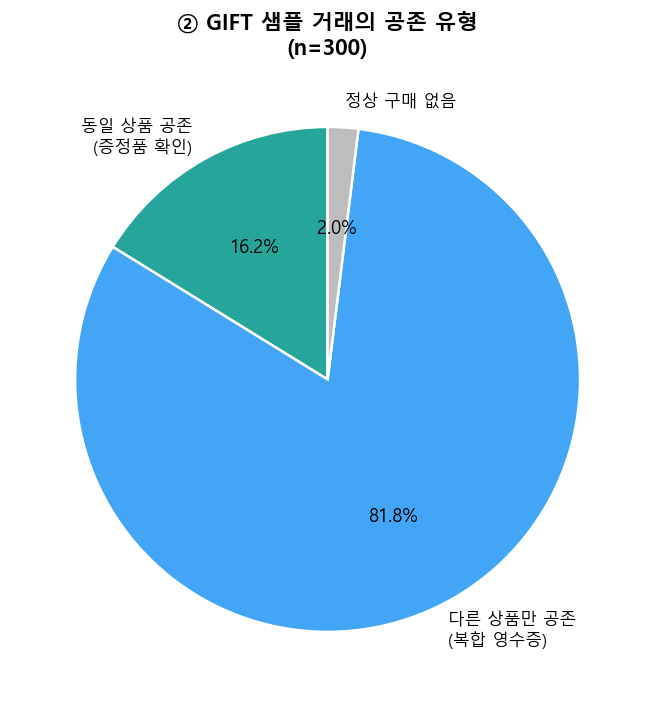

In [29]:
# 파이차트: 공존 유형 분포
labels = ['동일 상품 공존\n(증정품 확인)', '다른 상품만 공존\n(복합 영수증)', '정상 구매 없음']
sizes  = [
    cooc_tx,
    diff_item_cooc['거래_고유키'].nunique(),
    only_gift_tx
]
colors = ['#26A69A', '#42A5F5', '#BDBDBD']

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title(f'② GIFT 샘플 거래의 공존 유형\n(n={len(gift_sample_keys)})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_gift_cooccurrence.png'), dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# 동일 거래 내 이상치 상품과 동일한 카테고리(소분류)가 있는지 점검

# 금액=0 행에서 샘플 거래_고유키 추출 (최대 300건)
SAMPLE_N = 300
gift_sample_keys = (
    df_gift_amt0['거래_고유키'].drop_duplicates()
    .sample(n=min(SAMPLE_N, df_gift_amt0['거래_고유키'].nunique()), random_state=42)
    .tolist()
)
print(f'샘플 거래 수: {len(gift_sample_keys):,}건')

# 해당 거래의 전체 행 로드 (메인 파일에서 거래_고유키 필터)
print('메인 Parquet에서 샘플 거래 전체 행 로드 중...')
df_gift_tx = pd.read_parquet(
    PATH_MAIN,
    # 비교를 위해 '상품소분류명' 컬럼을 추가로 불러옵니다
    columns=['거래_고유키', '상품코드', '상품명', '상품소분류명', '매출수량', '매출금액', 'flag_이상치_유형'],
    filters=[('거래_고유키', 'in', gift_sample_keys)]
)
print(f'  로드 완료: {len(df_gift_tx):,}행')

# 증정행(금액=0)과 정상행(NORMAL) 각각 추출 (비교 대상을 '상품소분류명'으로 설정)
gift_rows   = df_gift_tx[df_gift_tx['매출금액'] == 0][['거래_고유키', '상품소분류명']].rename(columns={'상품소분류명': '증정_소분류'})
normal_rows = df_gift_tx[df_gift_tx['flag_이상치_유형'] == 'NORMAL'][['거래_고유키', '상품소분류명']].rename(columns={'상품소분류명': '정상_소분류'})

# 동일 거래 내 동일 '상품소분류명' 공존 여부 확인
cooc = gift_rows.merge(normal_rows, on='거래_고유키')
same_item_cooc = cooc[cooc['증정_소분류'] == cooc['정상_소분류']]
diff_item_cooc = cooc[cooc['증정_소분류'] != cooc['정상_소분류']]

cooc_tx = same_item_cooc['거래_고유키'].nunique()
only_gift_tx = len(set(gift_sample_keys) - set(normal_rows['거래_고유키']))

print(f'\n[샘플 {len(gift_sample_keys)}건 분석 결과]')
print(f'  동일 소분류 정상 구매 공존 (교차증정 등)  : {cooc_tx:>5}건  ({cooc_tx/len(gift_sample_keys)*100:.1f}%)')
print(f'  다른 소분류 정상 구매 공존 (일반 복합영수증): {diff_item_cooc["거래_고유키"].nunique():>5}건')
print(f'  정상 구매 없이 증정행만 존재              : {only_gift_tx:>5}건  ({only_gift_tx/len(gift_sample_keys)*100:.1f}%)')
print()

if cooc_tx > 0:
    print('→ 동일 소분류 공존 대다수 발견. (예: 교차 증정행사 품목)')
if only_gift_tx > 0:
    print('→ 정상 구매 없는 증정행은 별도 원인 분석 필요 (재고 조정, 시스템 보정 등)')

del df_gift_tx
gc.collect()

샘플 거래 수: 300건
메인 Parquet에서 샘플 거래 전체 행 로드 중...
  로드 완료: 2,283행

[샘플 300건 분석 결과]
  동일 소분류 정상 구매 공존 (교차증정 등)  :   172건  (57.3%)
  다른 소분류 정상 구매 공존 (일반 복합영수증):   264건
  정상 구매 없이 증정행만 존재              :     7건  (2.3%)

→ 동일 소분류 공존 대다수 발견. (예: 교차 증정행사 품목)
→ 정상 구매 없는 증정행은 별도 원인 분석 필요 (재고 조정, 시스템 보정 등)


6

### 수량 = 0 or 금액 = 0 이상치 결론:
(식품 카테고리에 한해)
- 해당 이상치에 속하는 모든 상품이 (금액=0 & 수량 >0)임. 증정품일 가능성이 높음
- 우리 프로젝트는 상품 속성을 바탕으로 상품의 구매력을 보고싶은 것이기에 증정 데이터 제거!

---
## ③ ZERO_AMT_NEG_QTY — 육안 데이터 검토

**수량 < 0 AND 금액 = 0** 인 행.  
물리적 해석: "마이너스 수량인데 돈은 안 건드린" 케이스.  
가능한 원인: **재고 조정, 파손/폐기 처리, 번들 취소 후 재처리** 등

#### 식품 단위로 보기

In [3]:
# 1. 식품 관련 대분류명 직접 지정
food_categories = [
    '음료', '과자', '유음료', '미반', '면', '냉장', '맥주', '즉석음료', '빵', '전통주', 
    '아이스크림', '조리빵', '즉석 식품', '건강/기호식품', '가공식품', '양주와인', '디저트', 
    '안주', '신선', '간식', '조미료/건물', '냉동'
]
# 2. 'ZERO_AMT_NEG_QTY' 이면서 지정한 대분류에 포함되는 행만 필터링
df_zero_neg = df_review[
    (df_review['flag_이상치_유형'] == 'ZERO_AMT_NEG_QTY') &
    (df_review['상품대분류명'].isin(food_categories))
].copy()
print(f'ZERO_AMT_NEG_QTY: {len(df_zero_neg):,}행')
print(f'  관련 상품 수: {df_zero_neg["상품코드"].nunique():,}개')
print(f'  관련 점포 수: {df_zero_neg["점포코드"].nunique():,}개')
print(f'  매출수량 통계:')
print(df_zero_neg['매출수량'].describe().to_string())

ZERO_AMT_NEG_QTY: 35,157행
  관련 상품 수: 4,976개
  관련 점포 수: 448개
  매출수량 통계:
count    35157.000000
mean        -1.360924
std          5.162649
min       -575.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max         -1.000000


In [4]:
# 실제 데이터 샘플 출력 (육안 확인)
display_cols = ['영업일자', '판매시분초', '점포코드', 'POS번호', '거래번호',
                '상품코드', '상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']

print('=' * 70)
print('[ZERO_AMT_NEG_QTY 샘플 — 랜덤 20행]')
print('=' * 70)
sample = df_zero_neg.sample(n=min(20, len(df_zero_neg)), random_state=42)
display(sample[[c for c in display_cols if c in df_zero_neg.columns]])

[ZERO_AMT_NEG_QTY 샘플 — 랜덤 20행]


,영업일자,판매시분초,점포코드,POS번호,거래번호,상품코드,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
1372525,20250619,182829,63387,2,5566,107538,동서)스타벅스카페모카320ml,300ml 이상,-1.0,0.0,2025-06-19 18:28:29
921712,20250307,14216,67326,1,32303,202695,동원)쿨피스톡제로복숭아340ml,제로탄산,-1.0,0.0,2025-03-07 01:42:16
2092538,20251201,230848,63813,1,53591,126827,삼립)초당옥수수미니꿀약과70g,구움과자,-2.0,0.0,2025-12-01 23:08:48
3181652,20251025,223219,18978,1,44487,202199,코카)몬스터(파이프라인펀치)355,에너지음료,-1.0,0.0,2025-10-25 22:32:19
2043778,20250825,234542,50513,2,67657,072487,대림)스노우크랩킹70g,맛살,-1.0,0.0,2025-08-25 23:45:42
3006112,20250909,130718,51877,2,89059,118528,오리온)그래놀라바단백질바40g,영양바류,-1.0,0.0,2025-09-09 13:07:18
430703,20250228,200350,68945,2,25201,124274,"삼립)1,900어니언치즈브레드100g",조리빵,-1.0,0.0,2025-02-28 20:03:50
2624496,20251226,213907,52669,2,95497,080915,한성)크래미140g,맛살,-1.0,0.0,2025-12-26 21:39:07
1951702,20250829,112632,11972,2,83090,107166,서울)커피타운바닐라250ml,300ml 미만,-1.0,0.0,2025-08-29 11:26:32
1722473,20250502,152946,68073,1,84632,601391,오리온)비쵸비5P,쿠키,-1.0,0.0,2025-05-02 15:29:46


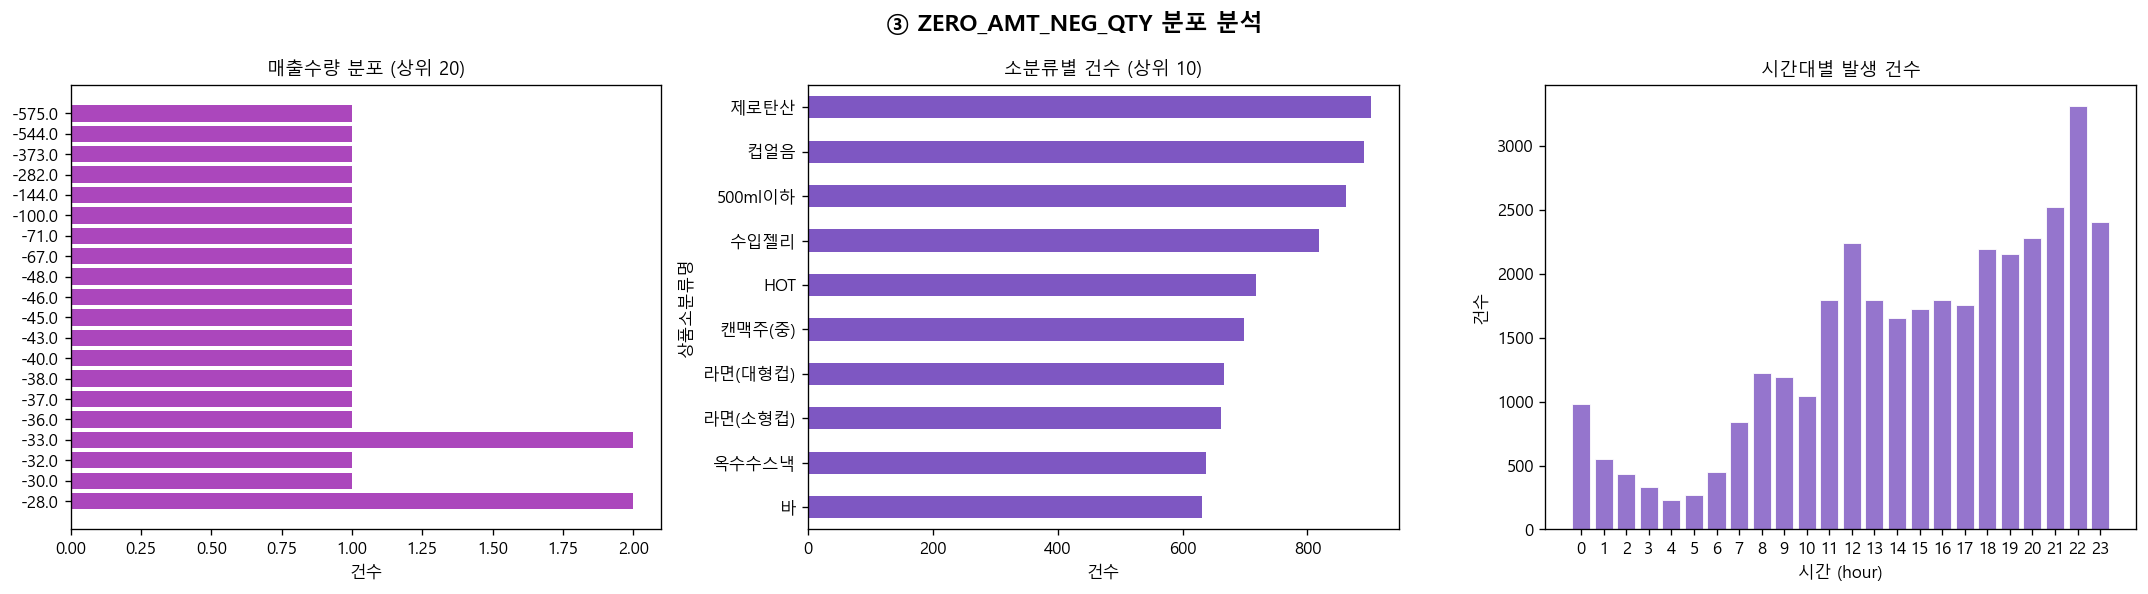


[ZERO_AMT_NEG_QTY 상위 10개 상품]


,,,건수,수량합
상품코드,상품명,상품소분류명,,
107128,PB)얼음컵(라지),컵얼음,389,-478.0
105078,세븐카페)텀블러200원할인,HOT,372,-461.0
202732,PB)내몸애70% 500ml,500ml이하,248,-277.0
107127,PB)얼음컵(레귤러),컵얼음,237,-349.0
070012,빙그레)바나나우유240ml,바나나우유,199,-241.0
201275,광동)제주삼다수500ml,500ml이하,192,-260.0
201105,칠성)아이시스500ml(8.0),500ml이하,188,-260.0
201276,광동)제주삼다수2.0L,1000ml이상,174,-197.0
202369,칠성)펩시콜라제로500ml,제로탄산,123,-183.0


In [5]:
# 수량별 / 카테고리별 / 점포별 분포
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('③ ZERO_AMT_NEG_QTY 분포 분석', fontsize=14, fontweight='bold')

# 매출수량 분포 (음수)
qty_dist = df_zero_neg['매출수량'].value_counts().sort_index().head(20)
axes[0].barh(qty_dist.index.astype(str), qty_dist.values, color='#AB47BC')
axes[0].set_title('매출수량 분포 (상위 20)', fontsize=11)
axes[0].set_xlabel('건수')
axes[0].invert_yaxis()

# 소분류 분포
cat_dist = df_zero_neg['상품소분류명'].value_counts().head(10)
cat_dist.plot(kind='barh', ax=axes[1], color='#7E57C2')
axes[1].set_title('소분류별 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('건수')
axes[1].invert_yaxis()

# 시간대 분포
hour_dist = df_zero_neg['판매시간대'].value_counts().sort_index()
axes[2].bar(hour_dist.index, hour_dist.values, color='#9575CD', edgecolor='white', linewidth=0.5)
axes[2].set_title('시간대별 발생 건수', fontsize=11)
axes[2].set_xlabel('시간 (hour)')
axes[2].set_ylabel('건수')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_zero_neg_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

# 상위 발생 상품
print('\n[ZERO_AMT_NEG_QTY 상위 10개 상품]')
display(
    df_zero_neg.groupby(['상품코드', '상품명', '상품소분류명'])
    .agg(건수=('매출수량', 'count'), 수량합=('매출수량', 'sum'))
    .sort_values('건수', ascending=False)
    .head(10)
)

In [6]:
import numpy as np

# 1. df_zero_neg에 존재하는 고유 상품코드 목록 추출
target_items = df_zero_neg['상품코드'].unique().tolist()
print(f"조사 대상 고유 상품 수: {len(target_items):,}개")

# 2. 메인 Parquet에서 해당 상품들의 정상(NORMAL) 판매 기록 로드
print("메인 데이터에서 정상 판매 기록 매칭 중 (시간이 다소 소요될 수 있습니다)...")
df_normal_sales = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', '상품코드', '판매시간_dt'],
    filters=[
        ('flag_이상치_유형', '=', 'NORMAL'),
        ('상품코드', 'in', target_items)
    ]
)
# Datetime 형식 보장
df_normal_sales['판매시간_dt'] = pd.to_datetime(df_normal_sales['판매시간_dt'], errors='coerce')

# 3. 점포별-상품별로 '최초 정상판매 시간' 및 '가장 최근 정상판매 시간' 추출
normal_summary = (
    df_normal_sales.dropna(subset=['판매시간_dt'])
    .groupby(['점포코드', '상품코드'])
    .agg(
        정상판매_최초시간=('판매시간_dt', 'min'),
        정상판매_최근시간=('판매시간_dt', 'max'),
        정상판매_총건수=('판매시간_dt', 'count')
    )
    .reset_index()
)
del df_normal_sales
gc.collect()

# 4. ZERO 데이터와 정상 판매 이력 병합 (점포코드 & 상품코드 기준 교집합/합집합)
df_zero_merged = df_zero_neg.merge(
    normal_summary, 
    on=['점포코드', '상품코드'], 
    how='left'
)
df_zero_merged['판매시간_dt'] = pd.to_datetime(df_zero_merged['판매시간_dt'], errors='coerce')

# 5. 성격 분류 로직 (Vectorized 적용으로 빠른 연산)
df_zero_merged['조정_성격'] = '판매이력 없음 (순수 재고조정/폐기 등)' # 기본값

has_history = df_zero_merged['정상판매_총건수'].notna()
sold_before_adj = has_history & (df_zero_merged['판매시간_dt'] >= df_zero_merged['정상판매_최초시간'])
adj_before_sold = has_history & (df_zero_merged['판매시간_dt'] < df_zero_merged['정상판매_최초시간'])

df_zero_merged.loc[sold_before_adj, '조정_성격'] = '판매이력 있음 (정상 판매 후 취소/조정)'
df_zero_merged.loc[adj_before_sold, '조정_성격'] = '판매이력 있음 (전산조정 후 추후 최초 판매됨)'

# 6. 통계 결과 출력
result_summary = df_zero_merged['조정_성격'].value_counts()
print("\n[ ZERO_AMT_NEG_QTY 성격 분석 결과 ]")
print("-" * 55)
for status, count in result_summary.items():
    pct = count / len(df_zero_merged) * 100
    print(f"  {status:<25}: {count:>8,}건  ({pct:>5.1f}%)")
print("-" * 55)

# 팁: DataFrame 형태로 상세히 확인하거나 결과를 시각화할 수 있습니다.
# display(df_zero_merged.groupby('조정_성격')[['매출수량']].sum().reset_index()) 


조사 대상 고유 상품 수: 4,976개
메인 데이터에서 정상 판매 기록 매칭 중 (시간이 다소 소요될 수 있습니다)...

[ ZERO_AMT_NEG_QTY 성격 분석 결과 ]
-------------------------------------------------------
  판매이력 있음 (정상 판매 후 취소/조정)  :   32,849건  ( 93.4%)
  판매이력 있음 (전산조정 후 추후 최초 판매됨):    1,538건  (  4.4%)
  판매이력 없음 (순수 재고조정/폐기 등)   :      770건  (  2.2%)
-------------------------------------------------------


### 수량만 음수이고 금액은 0 이상치 결론: (식품에 한해)

- 이 이상치는 2번 이상치의 환불 데이터임 (2번 이상치는 증정 상품 증정인 반면 3번 이상치는 증정 상품의 환불)
- 2번 이상치를 제거하는 결정을 내렸기 때문에 3번 이상치도 제거

---
## ④ PARTIAL_CANCEL — 부분 취소 분석

**수량 < 0 AND 금액 > 0** 인 행.  
물리적 해석: "수량은 반환했는데 금액은 양수"  
가능한 원인: **부분 취소 후 남은 금액 차액 처리, 쿠폰/포인트 사후 적용**

1. 어떤 상품·카테고리가 주로 부분 취소되는가?
2. 시간대/요일 패턴
3. 구매→취소 시간 텀

In [9]:
df_partial = df_review[df_review['flag_이상치_유형'] == 'PARTIAL_CANCEL'].copy()
print(f'PARTIAL_CANCEL: {len(df_partial):,}행')
print(f'  관련 상품 수      : {df_partial["상품코드"].nunique():,}개')
print(f'  관련 점포 수      : {df_partial["점포코드"].nunique():,}개')
print(f'  수량 통계: min={df_partial["매출수량"].min()}  mean={df_partial["매출수량"].mean():.2f}')
print(f'  금액 통계: min={df_partial["매출금액"].min()}  mean={df_partial["매출금액"].mean():.0f}  max={df_partial["매출금액"].max()}')
df_partial[['상품코드', '상품명', '상품소분류명', '매출수량', '매출금액', '판매시간_dt']]

PARTIAL_CANCEL: 16행
  관련 상품 수      : 2개
  관련 점포 수      : 10개
  수량 통계: min=-6.0  mean=-1.31
  금액 통계: min=151.0  mean=3333  max=28661.0


,상품코드,상품명,상품소분류명,매출수량,매출금액,판매시간_dt
396509,470293,스포츠토토 판매취소,스포츠토토,-1.0,151.0,2025-03-09 13:03:00
869358,470293,스포츠토토 판매취소,스포츠토토,-1.0,28661.0,2025-04-21 17:13:46
2071941,470293,스포츠토토 판매취소,스포츠토토,-1.0,597.0,2025-07-13 16:25:42
2291772,470293,스포츠토토 판매취소,스포츠토토,-1.0,298.0,2025-07-13 21:43:14
2292884,470293,스포츠토토 판매취소,스포츠토토,-1.0,597.0,2025-07-13 20:29:48
2292885,470293,스포츠토토 판매취소,스포츠토토,-1.0,597.0,2025-07-13 22:50:15
2565181,470293,스포츠토토 판매취소,스포츠토토,-1.0,597.0,2025-07-13 08:01:32
2565182,470293,스포츠토토 판매취소,스포츠토토,-1.0,1791.0,2025-07-13 22:36:11
3064448,470293,스포츠토토 판매취소,스포츠토토,-1.0,8073.0,2025-09-16 11:45:55
3081456,470293,스포츠토토 판매취소,스포츠토토,-1.0,1611.0,2025-07-13 12:56:57


### ④ - 1. 상위 부분취소 상품 & 카테고리

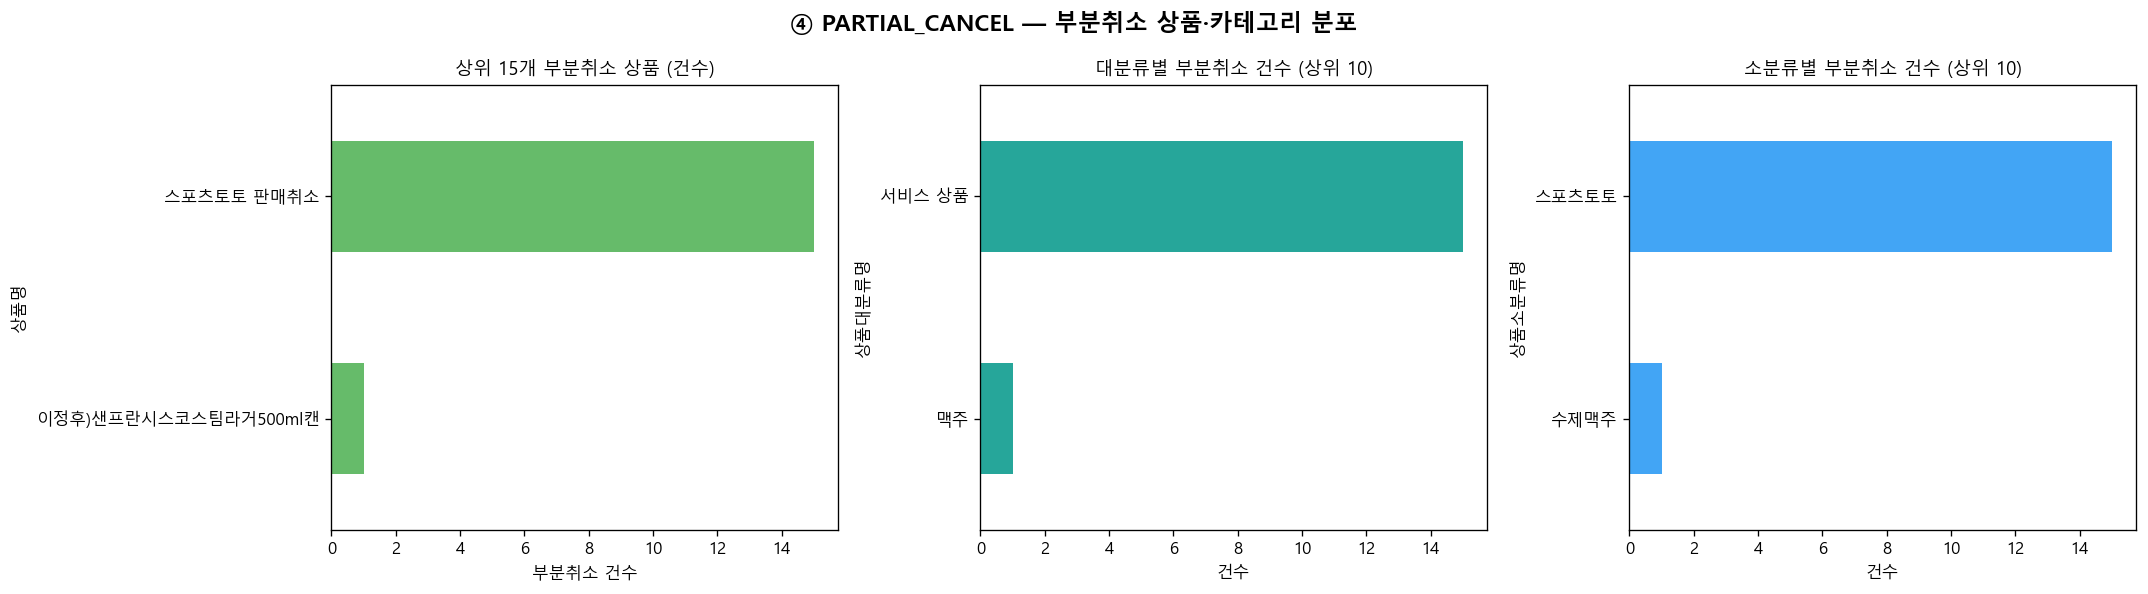


[상위 15개 부분취소 상품 세부]


,건수,금액합
상품명,,
스포츠토토 판매취소,15,47928.0
이정후)샌프란시스코스팀라거500ml캔,1,5400.0


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('④ PARTIAL_CANCEL — 부분취소 상품·카테고리 분포', fontsize=14, fontweight='bold')

# 상위 상품 (건수)
top_pc_items = df_partial.groupby('상품명').agg(
    건수=('매출수량', 'count'),
    금액합=('매출금액', 'sum')
).sort_values('건수', ascending=False).head(15)
top_pc_items['건수'].plot(kind='barh', ax=axes[0], color='#66BB6A')
axes[0].set_title('상위 15개 부분취소 상품 (건수)', fontsize=11)
axes[0].set_xlabel('부분취소 건수')
axes[0].invert_yaxis()

# 대분류 분포
cat_l = df_partial['상품대분류명'].value_counts().head(10)
cat_l.plot(kind='barh', ax=axes[1], color='#26A69A')
axes[1].set_title('대분류별 부분취소 건수 (상위 10)', fontsize=11)
axes[1].set_xlabel('건수')
axes[1].invert_yaxis()

# 소분류 분포
cat_s = df_partial['상품소분류명'].value_counts().head(10)
cat_s.plot(kind='barh', ax=axes[2], color='#42A5F5')
axes[2].set_title('소분류별 부분취소 건수 (상위 10)', fontsize=11)
axes[2].set_xlabel('건수')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_partial_products.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n[상위 15개 부분취소 상품 세부]')
display(top_pc_items)

### ④ - 2. 시간대 / 요일 패턴

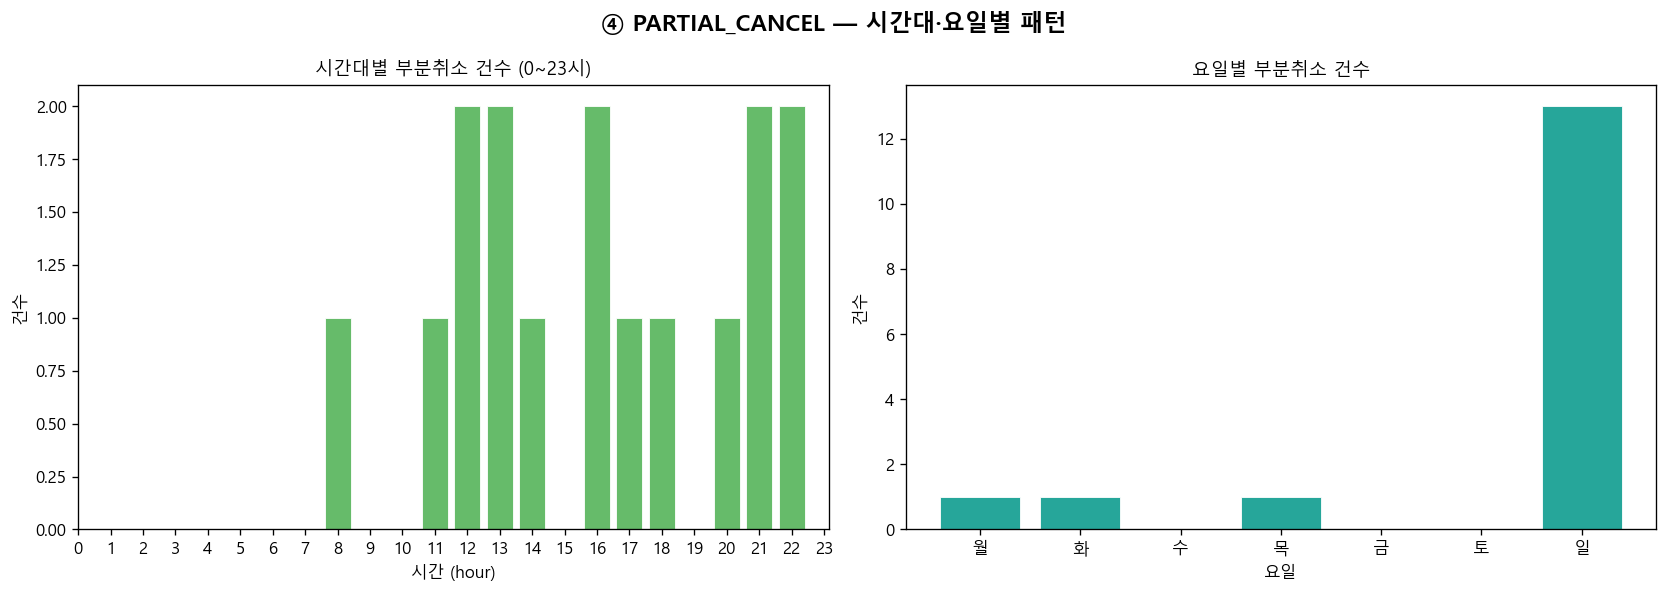

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('④ PARTIAL_CANCEL — 시간대·요일별 패턴', fontsize=14, fontweight='bold')

hour_dist = df_partial['판매시간대'].value_counts().sort_index()
axes[0].bar(hour_dist.index, hour_dist.values, color='#66BB6A', edgecolor='white', linewidth=0.5)
axes[0].set_title('시간대별 부분취소 건수 (0~23시)', fontsize=11)
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('건수')
axes[0].set_xticks(range(0, 24))

day_order = ['월', '화', '수', '목', '금', '토', '일']
day_dist  = df_partial['판매요일'].value_counts().reindex(day_order).fillna(0)
axes[1].bar(day_dist.index, day_dist.values, color='#26A69A', edgecolor='white', linewidth=0.5)
axes[1].set_title('요일별 부분취소 건수', fontsize=11)
axes[1].set_xlabel('요일')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_partial_time_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

### ④ - 3. 부분취소 시간 텀 분석

> ⏳ REFUND 분석과 동일한 방식 — 메인 파일에서 해당 상품의 NORMAL 행을 로드합니다.

In [20]:
TOP_N = 50
top_partial_items = df_partial['상품코드'].value_counts().head(TOP_N).index.tolist()
print(f'시간 텀 분석 대상: 상위 {TOP_N}개 상품')

print('메인 Parquet에서 NORMAL 행 로드 중...')
df_normal_p = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', '상품코드', '상품명', '판매시간_dt'],
    filters=[
        ('flag_이상치_유형', '=', 'NORMAL'),
        ('상품코드', 'in', top_partial_items)
    ]
)
df_normal_p['판매시간_dt'] = pd.to_datetime(df_normal_p['판매시간_dt'], errors='coerce')
df_normal_p = df_normal_p.dropna(subset=['판매시간_dt'])
print(f'  로드 완료: {len(df_normal_p):,}행')

partial_sub = (
    df_partial[df_partial['상품코드'].isin(top_partial_items)]
    [['점포코드', '상품코드', '상품명', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '취소시간'})
    .dropna(subset=['취소시간'])
    .sort_values('취소시간')
)
normal_p_sub = (
    df_normal_p[['점포코드', '상품코드', '판매시간_dt']]
    .rename(columns={'판매시간_dt': '구매시간'})
    .sort_values('구매시간')
)

df_gap_p = pd.merge_asof(
    partial_sub,
    normal_p_sub,
    left_on='취소시간',
    right_on='구매시간',
    by=['점포코드', '상품코드'],
    direction='backward'
)
df_gap_p['시간_텀_h'] = (df_gap_p['취소시간'] - df_gap_p['구매시간']).dt.total_seconds() / 3600
df_gap_p['일_텀']    = (df_gap_p['시간_텀_h'] / 24).round(1)

valid_gap_p = df_gap_p.dropna(subset=['시간_텀_h'])
valid_gap_p = valid_gap_p[valid_gap_p['시간_텀_h'] >= 0]

매칭률_p = len(valid_gap_p) / len(partial_sub) * 100
print(f'\n매칭 성공: {len(valid_gap_p):,}건 / {len(partial_sub):,}건 ({매칭률_p:.1f}%)')
print(f'  중앙 시간 텀 : {valid_gap_p["시간_텀_h"].median():.1f}시간')
print(f'  평균 시간 텀 : {valid_gap_p["시간_텀_h"].mean():.1f}시간')
print(f'  중앙 일수 텀 : {valid_gap_p["일_텀"].median():.1f}일')

del df_normal_p
gc.collect()

시간 텀 분석 대상: 상위 50개 상품
메인 Parquet에서 NORMAL 행 로드 중...
  로드 완료: 1,765행

매칭 성공: 1건 / 16건 (6.2%)
  중앙 시간 텀 : 0.4시간
  평균 시간 텀 : 0.4시간
  중앙 일수 텀 : 0.0일


30982

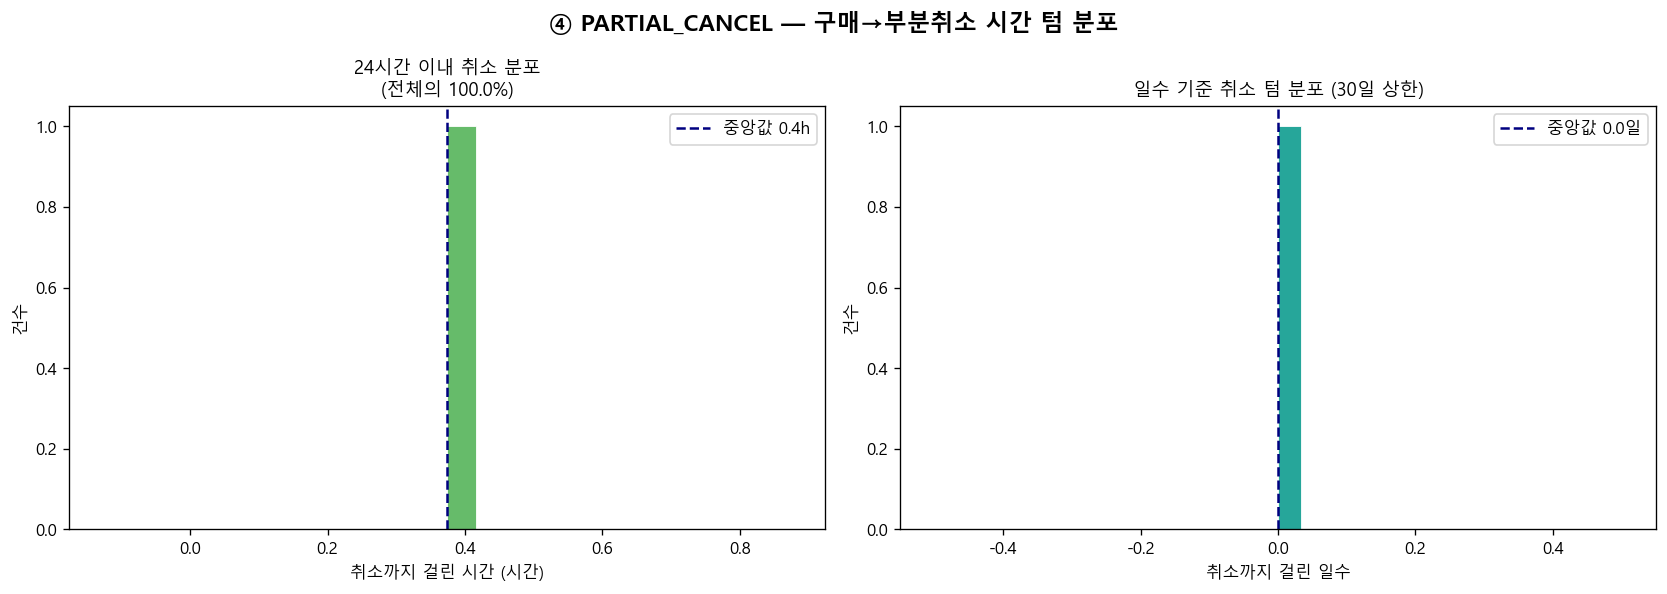

[부분취소 텀 구간 비중]
  당일(0~24h)   :       1건  (100.0%)
  1~3일        :       0건  (0.0%)
  3~7일        :       0건  (0.0%)
  7일 초과       :       0건  (0.0%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('④ PARTIAL_CANCEL — 구매→부분취소 시간 텀 분포', fontsize=14, fontweight='bold')

within_24h_p = valid_gap_p[valid_gap_p['시간_텀_h'] <= 24]['시간_텀_h']
axes[0].hist(within_24h_p, bins=24, color='#66BB6A', edgecolor='white', linewidth=0.5)
axes[0].set_title(f'24시간 이내 취소 분포\n(전체의 {len(within_24h_p)/len(valid_gap_p)*100:.1f}%)', fontsize=11)
axes[0].set_xlabel('취소까지 걸린 시간 (시간)')
axes[0].set_ylabel('건수')
if len(within_24h_p) > 0:
    axes[0].axvline(within_24h_p.median(), color='navy', linestyle='--',
                    label=f'중앙값 {within_24h_p.median():.1f}h')
    axes[0].legend()

day_dist_p = valid_gap_p['일_텀'].clip(upper=30)
axes[1].hist(day_dist_p, bins=30, color='#26A69A', edgecolor='white', linewidth=0.5)
axes[1].set_title('일수 기준 취소 텀 분포 (30일 상한)', fontsize=11)
axes[1].set_xlabel('취소까지 걸린 일수')
axes[1].set_ylabel('건수')
axes[1].axvline(valid_gap_p['일_텀'].median(), color='navy', linestyle='--',
                label=f'중앙값 {valid_gap_p["일_텀"].median():.1f}일')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, 'fig_partial_time_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('[부분취소 텀 구간 비중]')
for label, lo, hi in [('당일(0~24h)', 0, 24), ('1~3일', 24, 72), ('3~7일', 72, 168), ('7일 초과', 168, 1e9)]:
    cnt = ((valid_gap_p['시간_텀_h'] >= lo) & (valid_gap_p['시간_텀_h'] < hi)).sum()
    print(f'  {label:<12}: {cnt:>7,}건  ({cnt/len(valid_gap_p)*100:.1f}%)')

이정후 수제 맥주는 IP 콜라보니까 살리고 싶음

In [10]:
# 1. 대상 상품코드 (6자리 문자열 포맷팅)
target_item_code = str(127820).zfill(6)
print(f"조회 대상 상품코드: {target_item_code}")

# 2. 메인 Parquet 파일에서 해당 상품코드의 전체 이력(정상 + 모든 이상치) 로드
print("해당 상품의 전체 거래 내역 로딩 중...")
df_item_history = pd.read_parquet(
    PATH_MAIN,
    columns=['점포코드', 'POS번호', '거래번호', '판매시간_dt', '상품코드', '상품명', '매출수량', '매출금액', 'flag_이상치_유형'],
    filters=[('상품코드', '=', target_item_code)]
)

# Datetime 형식 보장
df_item_history['판매시간_dt'] = pd.to_datetime(df_item_history['판매시간_dt'], errors='coerce')

# 3. 결과 요약 및 출력
if not df_item_history.empty:
    # 점포별, 시간순으로 정렬하여 전후 맥락을 파악하기 쉽게 정렬
    df_item_history = df_item_history.sort_values(by=['점포코드', '판매시간_dt']).reset_index(drop=True)
    
    anomaly_records = df_item_history[df_item_history['flag_이상치_유형'] != 'NORMAL']
    print(f"\n✅ 데이터 로드 완료: 총 {len(df_item_history):,}건 조회")
    print(f"  - 정상 판매 분 : {len(df_item_history) - len(anomaly_records):,}건")
    print(f"  - 이상치 기록  : {len(anomaly_records):,}건")
    
    # 4번 이상치(DATA_SUSPECT 등)가 있는 행과 그 전후로 어떤 일들이 있었는지 먼저 확인
    print("\n🔍 [이상치 포함 판매 기록 (최대 50건 표시)]")
    # 전체 기록 출력 (Jupyter 에서는 display 사용)
    display(df_item_history.head(50))
    
    # 특정 4번 이상치 내용만 따로 보고 싶을 경우 아래 주석을 해제하세요
    # display(df_item_history[df_item_history['flag_이상치_유형'] == 'DATA_SUSPECT'])

else:
    print(f"\n❌ 해당 상품코드({target_item_code})에 대한 판매 기록이 존재하지 않습니다.")


조회 대상 상품코드: 127820
해당 상품의 전체 거래 내역 로딩 중...

✅ 데이터 로드 완료: 총 1,886건 조회
  - 정상 판매 분 : 1,765건
  - 이상치 기록  : 121건

🔍 [이상치 포함 판매 기록 (최대 50건 표시)]


,점포코드,POS번호,거래번호,판매시간_dt,상품코드,상품명,매출수량,매출금액,flag_이상치_유형
0,10001,2,95334,2025-09-01 20:52:46,127820,이정후)샌프란시스코스팀라거500ml캔,2.0,9800.0,NORMAL
1,10001,2,98347,2025-09-07 14:07:07,127820,이정후)샌프란시스코스팀라거500ml캔,4.0,13000.0,NORMAL
2,10004,2,73933,2025-12-11 14:45:35,127820,이정후)샌프란시스코스팀라거500ml캔,4.0,4000.0,NORMAL
3,10005,2,19383,2025-10-17 22:48:55,127820,이정후)샌프란시스코스팀라거500ml캔,1.0,3250.0,NORMAL
4,10005,2,32778,2025-11-07 16:16:03,127820,이정후)샌프란시스코스팀라거500ml캔,1.0,4900.0,NORMAL
5,10005,1,74097,2025-12-12 03:37:09,127820,이정후)샌프란시스코스팀라거500ml캔,4.0,4000.0,NORMAL
6,10009,1,29598,2025-09-06 00:12:48,127820,이정후)샌프란시스코스팀라거500ml캔,1.0,4900.0,NORMAL
7,10009,1,37754,2025-10-03 22:39:07,127820,이정후)샌프란시스코스팀라거500ml캔,4.0,13000.0,NORMAL
8,10009,1,43600,2025-10-24 22:33:45,127820,이정후)샌프란시스코스팀라거500ml캔,2.0,6500.0,NORMAL
9,10009,2,72870,2025-12-09 09:34:28,127820,이정후)샌프란시스코스팀라거500ml캔,11.0,11000.0,NORMAL


### 수량<0, 금액 >0 이상치 관련 (식품에 한해)

- 식품인 이상치는 이정후 맥주밖에 없는데, 이는 이상치로 판별됨. -> 제거

---
## 분석 요약

위 분석 결과를 바탕으로 각 플래그의 처리 방향을 아래 표에 기록하세요.

| 플래그 | 분석 결과 요약 | 처리 방향 (삭제/유지/별도관리) |
|--------|--------------|--------------------------------|
| REFUND_NEGATIVE | | |
| GIFT_OR_ZERO_QTY | | |
| ZERO_AMT_NEG_QTY | | |
| PARTIAL_CANCEL | | |
| DATA_SUSPECT | 물리적으로 모순(수량+/금액-) → 시스템 오류 유력 | 삭제 |

In [ ]:
# 저장된 시각화 파일 목록 확인
print('💾 저장된 분석 시각화 파일:')
for f in sorted(os.listdir(FINAL_DIR)):
    if f.startswith('fig_') and f.endswith('.png'):
        path = os.path.join(FINAL_DIR, f)
        print(f'  {f}  ({os.path.getsize(path)/1e3:.0f} KB)')